In [1]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [2]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [3]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

## Read in MSA

In [37]:
import json
from pathlib import Path

def load_snp_dict(json_path: str):
    with open(json_path, "r") as f:
        return json.load(f)

def get_run_blocks_from_details(side_block: dict, *, use_details: bool = True):
    """
    Build consecutive run blocks (Agree/Disagree) along coordinates.

    Prefers *_details (more accurate, preserves multiple events at same coord if present).
    Falls back to *_coords if details are missing.

    Returns a list of blocks:
      {
        "state": "Agree" | "Disagree",
        "start": int,
        "end": int,
        "n_sites": int,
        "coords": [int, ...]
      }
    """
    agree_details = side_block.get("agree_details")
    disagree_details = side_block.get("disagree_details")

    sites = []

    if use_details and isinstance(agree_details, list) and isinstance(disagree_details, list):
        for d in agree_details:
            if "coord" in d:
                sites.append((int(d["coord"]), "Agree"))
        for d in disagree_details:
            if "coord" in d:
                sites.append((int(d["coord"]), "Disagree"))
    else:
        for c in side_block.get("agree_coords", []):
            sites.append((int(c), "Agree"))
        for c in side_block.get("disagree_coords", []):
            sites.append((int(c), "Disagree"))

    if not sites:
        return []

    sites.sort(key=lambda x: (x[0], 0 if x[1] == "Agree" else 1))

    collapsed = []
    i = 0
    while i < len(sites):
        coord = sites[i][0]
        states = []
        j = i
        while j < len(sites) and sites[j][0] == coord:
            states.append(sites[j][1])
            j += 1
        if len(states) == 1:
            collapsed.append((coord, states[0]))
        else:
            a = sum(1 for s in states if s == "Agree")
            d = sum(1 for s in states if s == "Disagree")
            if a > d:
                collapsed.append((coord, "Agree"))
            elif d > a:
                collapsed.append((coord, "Disagree"))
            else:
                collapsed.append((coord, "Mixed"))
        i = j

    blocks = []
    cur_state = collapsed[0][1]
    cur_coords = [collapsed[0][0]]

    for coord, state in collapsed[1:]:
        if state == cur_state:
            cur_coords.append(coord)
        else:
            blocks.append({
                "state": cur_state,
                "start": cur_coords[0],
                "end": cur_coords[-1],
                "n_sites": len(cur_coords),
                "coords": cur_coords,
            })
            cur_state = state
            cur_coords = [coord]

    blocks.append({
        "state": cur_state,
        "start": cur_coords[0],
        "end": cur_coords[-1],
        "n_sites": len(cur_coords),
        "coords": cur_coords,
    })

    return blocks


def merge_adjacent_same_state(blocks):
    """
    Merge consecutive blocks that have the same 'state' (Agree/Disagree/Mixed).
    Assumes blocks are already in coordinate order.
    """
    if not blocks:
        return []

    merged = [blocks[0].copy()]
    for b in blocks[1:]:
        last = merged[-1]
        if b["state"] == last["state"]:
            # merge
            last["end"] = b["end"]
            last["n_sites"] += b["n_sites"]
            last["coords"] = last["coords"] + b["coords"]
        else:
            merged.append(b.copy())
    return merged



def compute_gap_windows_between_blocks(blocks, *, include_edges=False, seq_min=None, seq_max=None):
    """
    Given ordered, non-overlapping blocks (with start/end), return the windows BETWEEN them.

    A "gap window" is:
      prev_block.end  -> next_block.start

    By default we return the *open interval* between blocks using the nearest SNP coords:
      gap_start = prev.end
      gap_end   = next.start

    If you prefer a strict empty window (no shared endpoints), use:
      gap_start = prev.end + 1
      gap_end   = next.start - 1

    Parameters
    ----------
    blocks : list of dicts (must contain start/end/state)
    include_edges : bool
        If True and seq_min/seq_max provided, also return leading and trailing gaps.
    seq_min, seq_max : int | None
        Coordinate bounds for edge gaps (optional).

    Returns
    -------
    gaps : list of dicts
      {
        "gap_start": int,
        "gap_end": int,
        "gap_len": int,
        "left_state": str,
        "right_state": str,
        "left_end": int,
        "right_start": int
      }
    """
    if not blocks:
        return []

    blocks = sorted(blocks, key=lambda b: (b["start"], b["end"]))

    gaps = []

    if include_edges and (seq_min is not None):
        first = blocks[0]
        if seq_min < first["start"]:
            gaps.append({
                "gap_start": int(seq_min),
                "gap_end": int(first["start"]),
                "gap_len": int(first["start"] - seq_min),
                "left_state": None,
                "right_state": first["state"],
                "left_end": None,
                "right_start": int(first["start"]),
            })

    for left, right in zip(blocks, blocks[1:]):
        gap_start = int(left["end"]) + 1
        gap_end   = int(right["start"]) - 1

        if gap_end < gap_start:
            continue

        gaps.append({
            "gap_start": gap_start,
            "gap_end": gap_end,
            "gap_len": int(gap_end - gap_start),
            "left_state": left["state"],
            "right_state": right["state"],
            "left_end": int(left["end"]),
            "right_start": int(right["start"]),
        })


    if include_edges and (seq_max is not None):
        last = blocks[-1]
        if last["end"] < seq_max:
            gaps.append({
                "gap_start": int(last["end"]),
                "gap_end": int(seq_max),
                "gap_len": int(seq_max - last["end"]),
                "left_state": last["state"],
                "right_state": None,
                "left_end": int(last["end"]),
                "right_start": None,
            })

    return gaps


directory = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/BreakpointInformation/"
jsonFile  = "DELETION_HG04228_HG04115_deletion_breakpoint.no_gap_cols.deleted_two_panels.snp_dict.json"
json_path = Path(directory) / jsonFile

snp_dict = load_snp_dict(str(json_path))

group = list(snp_dict.keys())[0]
block_5prime = snp_dict[group]["FULL_5prime"]


blocks = get_run_blocks_from_details(block_5prime, use_details=True)
blocks = [b for b in blocks if b["n_sites"] >= 2]
blocks = merge_adjacent_same_state(blocks)

gaps = compute_gap_windows_between_blocks(blocks)


for b in blocks[:20]:
    print(f"{b['state']:8s}  n={b['n_sites']:4d}  {b['start']}-{b['end']}")

print("Potential breakpoint windows (gaps between blocks):", len(gaps))
print("\nFirst 20 gap windows:")
for g in gaps[:20]:
    print(f"{g['gap_start']}-{g['gap_end']} (len={g['gap_len']})   {g['left_state']} -> {g['right_state']}")

Agree     n=  11  24224663-24240741
Disagree  n=  13  24249712-24273462
Potential breakpoint windows (gaps between blocks): 1

First 20 gap windows:
24240742-24249711 (len=8969)   Agree -> Disagree



=== NA18952_HG02572_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 445670 / 471261
[DEBUG] SNP columns (no-gap; bases only): 307
[DEBUG] NA18952_chrY (DELETED) vs HG02572_chrY (FULL): skipped(full5==full3 & del!=full)=37


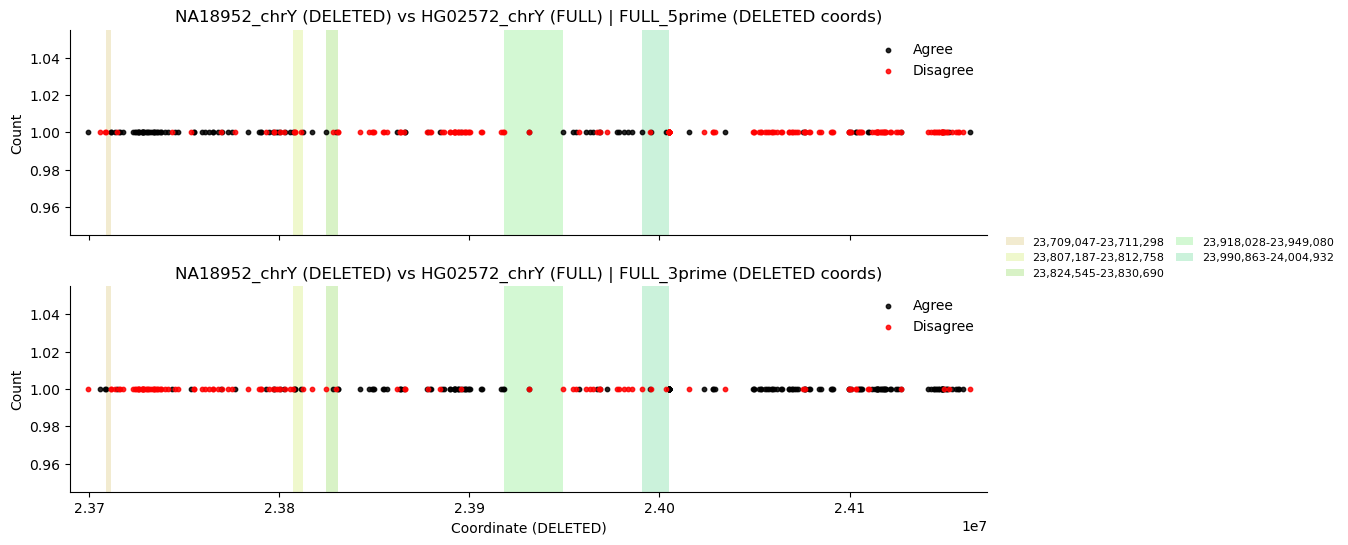


=== NA18983_HG02572_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 432445 / 478477
[DEBUG] SNP columns (no-gap; bases only): 289
[DEBUG] NA18983_chrY (DELETED) vs HG02572_chrY (FULL): skipped(full5==full3 & del!=full)=53


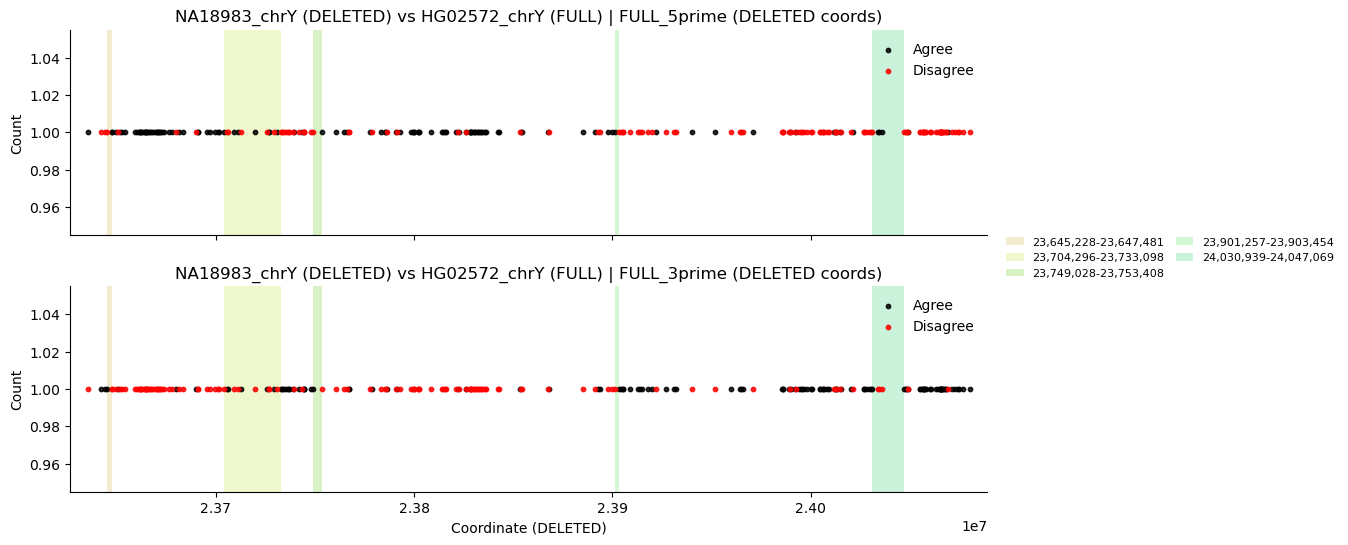


=== HG01099_HG03579_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 437226 / 476019
[DEBUG] SNP columns (no-gap; bases only): 301
[DEBUG] HG01099_chrY (DELETED) vs HG03579_chrY (FULL): skipped(full5==full3 & del!=full)=14


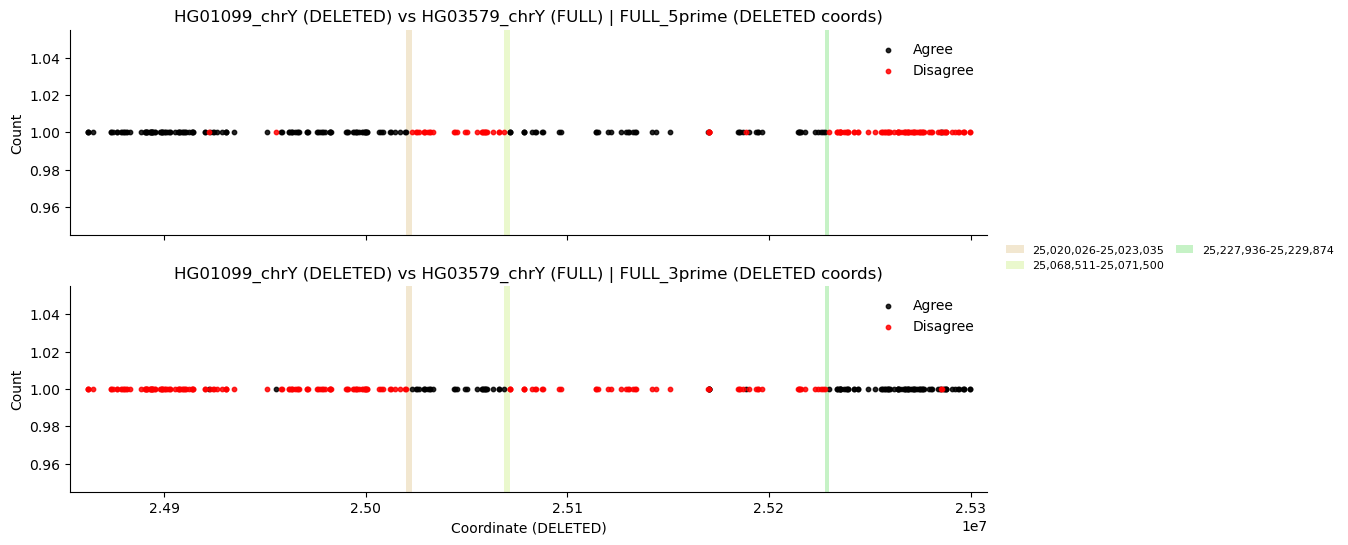


=== HG04228_HG04115_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 49959 / 50045
[DEBUG] SNP columns (no-gap; bases only): 28
[DEBUG] HG04228_chrY (DELETED) vs HG04115_chrY (FULL): skipped(full5==full3 & del!=full)=3


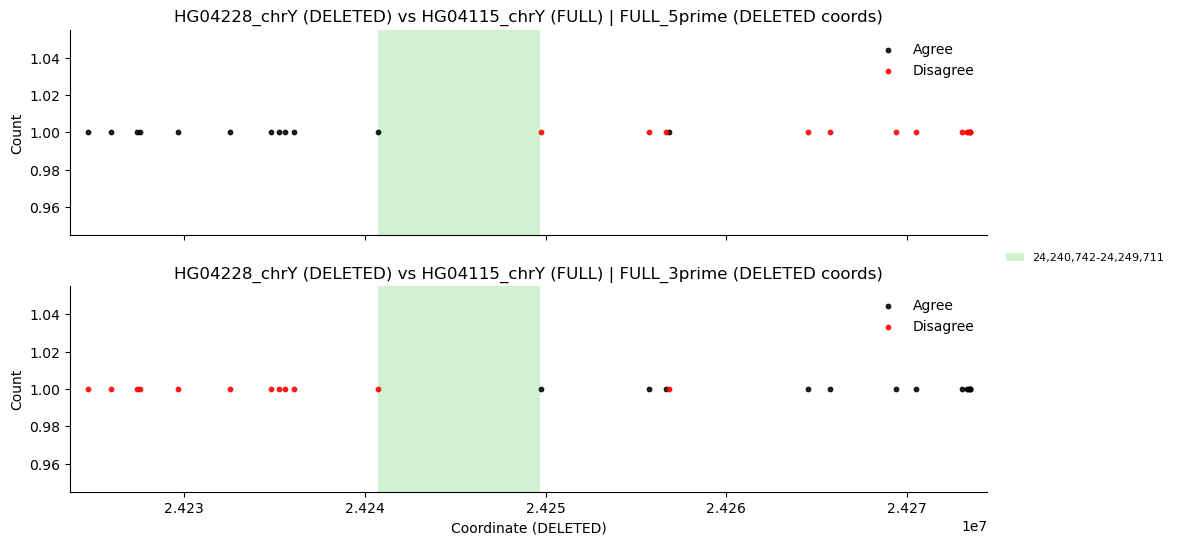


=== NA18747_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364531 / 364913
[DEBUG] SNP columns (no-gap; bases only): 236
[DEBUG] NA18747_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=34


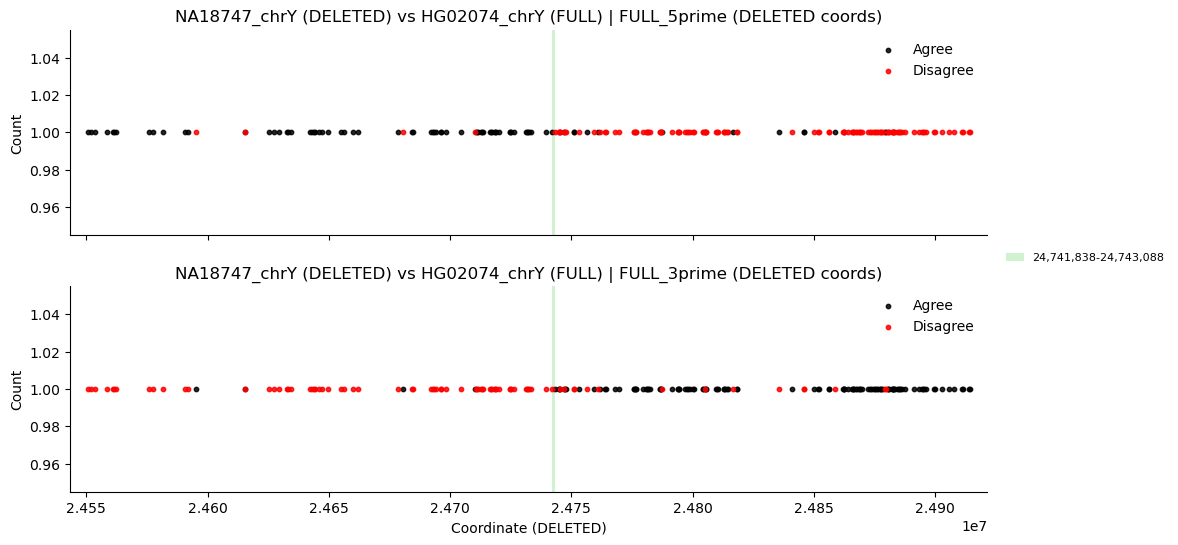


=== HG00290_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364542 / 365169
[DEBUG] SNP columns (no-gap; bases only): 242
[DEBUG] HG00290_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=31


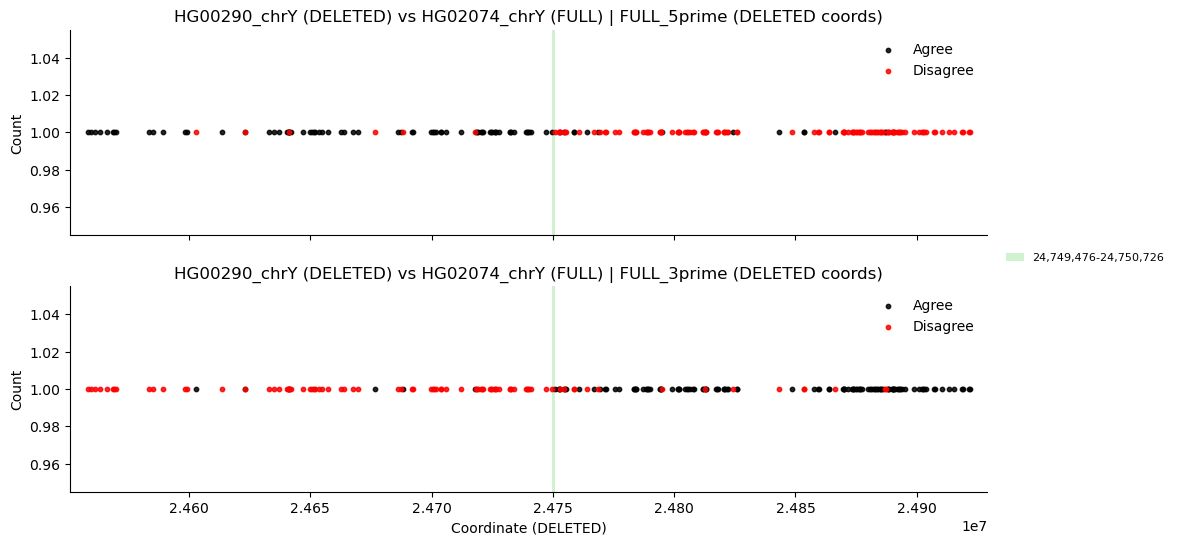


=== HG02135_HG02071_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 314626 / 314773
[DEBUG] SNP columns (no-gap; bases only): 184
[DEBUG] HG02135_chrY (DELETED) vs HG02071_chrY (FULL): skipped(full5==full3 & del!=full)=7


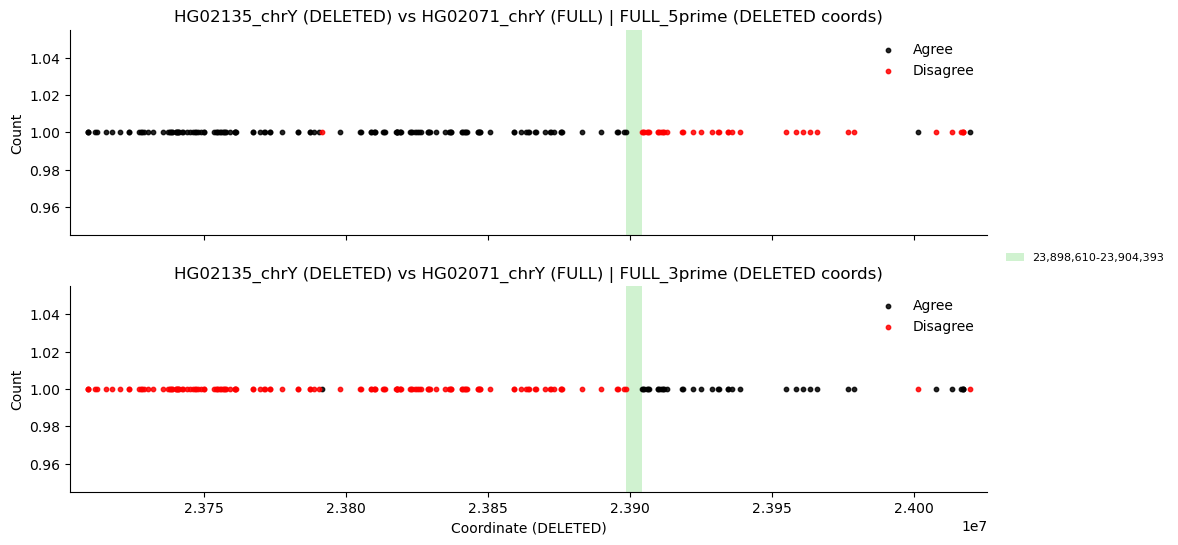


=== HG02129_HG02071_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 314630 / 314777
[DEBUG] SNP columns (no-gap; bases only): 209
[DEBUG] HG02129_chrY (DELETED) vs HG02071_chrY (FULL): skipped(full5==full3 & del!=full)=7


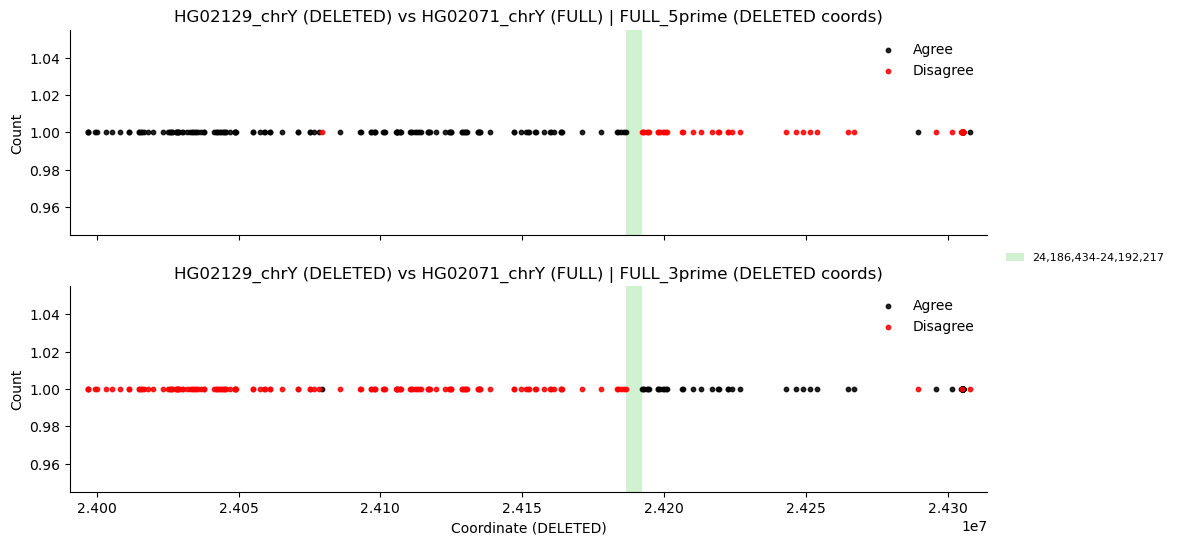


=== HG00358_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364576 / 365142
[DEBUG] SNP columns (no-gap; bases only): 238
[DEBUG] HG00358_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=31


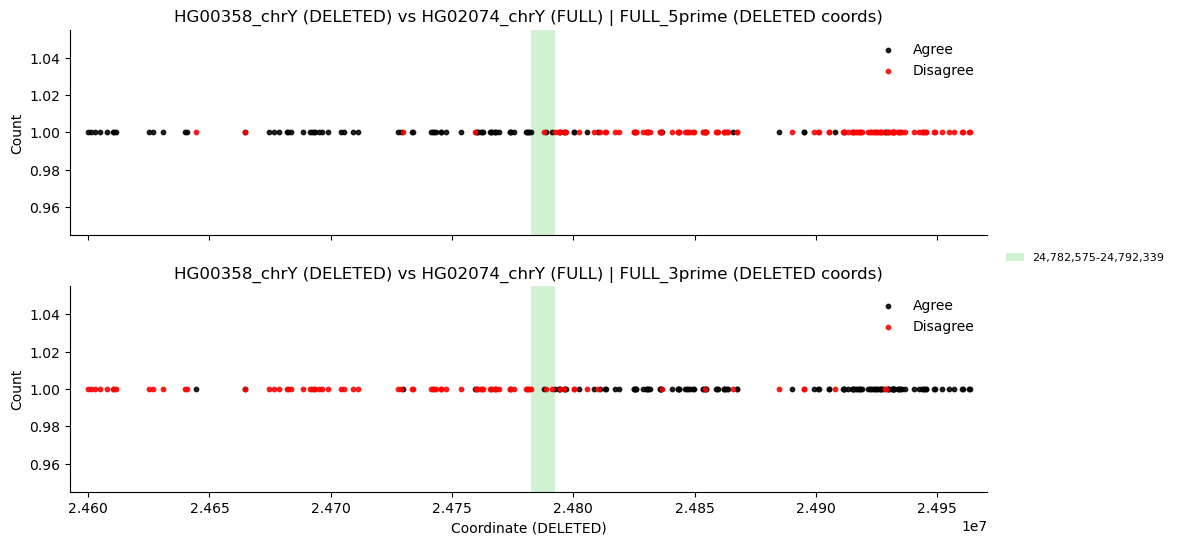


=== HG00329_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364590 / 365133
[DEBUG] SNP columns (no-gap; bases only): 350
[DEBUG] HG00329_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=145


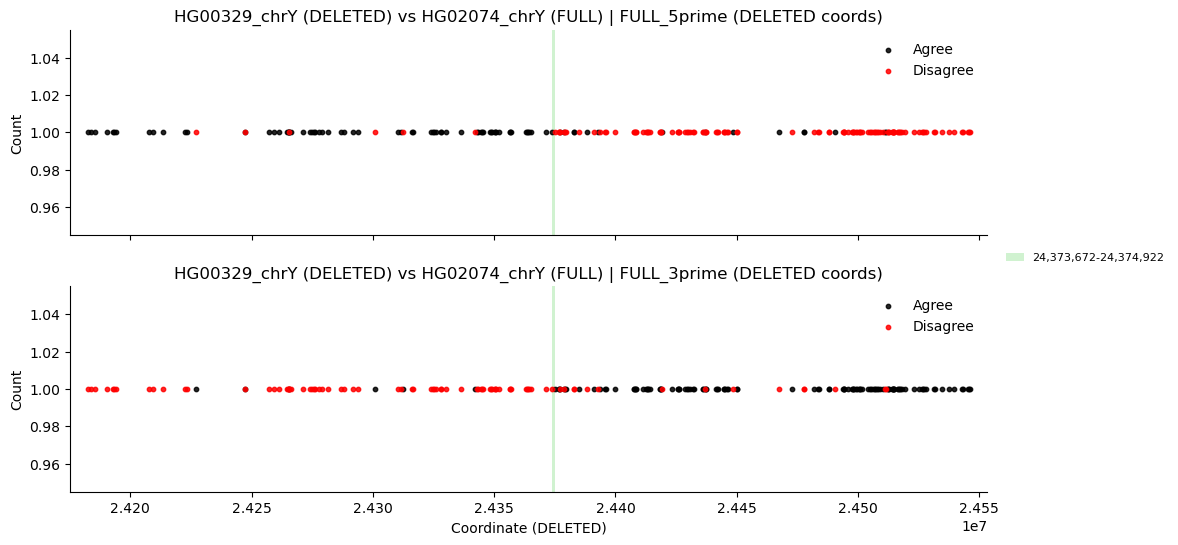


=== HG005_HG02572_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 445698 / 473657
[DEBUG] SNP columns (no-gap; bases only): 300
[DEBUG] HG005_chrY (DELETED) vs HG02572_chrY (FULL): skipped(full5==full3 & del!=full)=43


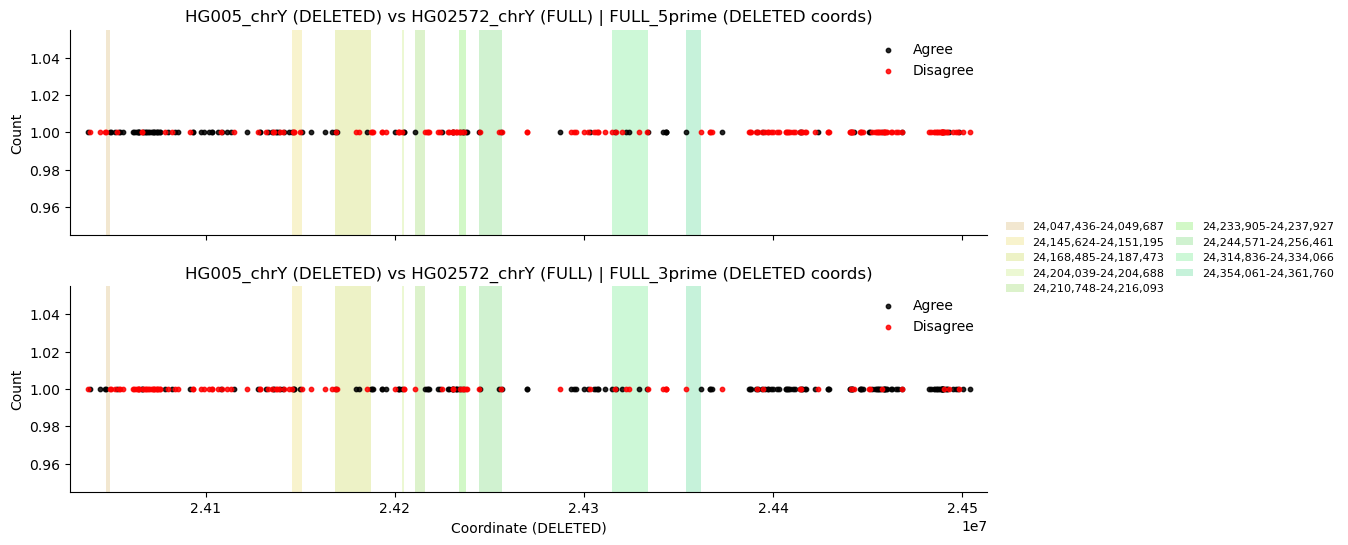

In [61]:
from __future__ import annotations

import os
import re
import json
from pathlib import Path
from typing import Union, List, Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def msa_fasta_to_df(
    fasta_path: Union[str, Path],
    *,
    long: bool = False,
    keep_gaps: bool = True,
    fill_value: str = "-",
) -> pd.DataFrame:
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {fasta_path}")

    seqs: Dict[str, str] = {}
    cur_id = None
    cur_chunks: List[str] = []

    def _commit():
        nonlocal cur_id, cur_chunks
        if cur_id is None:
            return
        seq = "".join(cur_chunks).strip()
        if not seq:
            raise ValueError(f"Empty sequence for record '{cur_id}' in {fasta_path}")
        if cur_id in seqs:
            raise ValueError(f"Duplicate FASTA header/id '{cur_id}' in {fasta_path}")
        seqs[cur_id] = seq
        cur_id, cur_chunks = None, []

    with fasta_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                _commit()
                cur_id = line[1:].split()[0]
                cur_chunks = []
            else:
                if cur_id is None:
                    raise ValueError("FASTA parse error: sequence line before any header ('>').")
                cur_chunks.append(line)
    _commit()

    if not seqs:
        raise ValueError(f"No sequences found in {fasta_path}")

    max_len = max(len(s) for s in seqs.values())
    ids = list(seqs.keys())
    mat = []
    for i in ids:
        s = seqs[i]
        if len(s) < max_len:
            s = s + (fill_value * (max_len - len(s)))
        elif len(s) > max_len:
            s = s[:max_len]
        mat.append(list(s))

    wide = pd.DataFrame(mat, index=ids, columns=pd.RangeIndex(1, max_len + 1, name="pos"))
    wide.index.name = "id"

    if not keep_gaps:
        wide = wide.replace("-", pd.NA)

    if not long:
        return wide

    long_df = (
        wide.reset_index()
            .melt(id_vars="id", var_name="pos", value_name="base")
            .sort_values(["id", "pos"], kind="stable")
            .reset_index(drop=True)
    )
    if not keep_gaps:
        long_df.loc[long_df["base"] == "-", "base"] = pd.NA
    return long_df


REGION_RE = re.compile(
    r"^(?P<contig>[^:]+):(?P<start>\d+)-(?P<end>\d+)_(?P<role>DELETED|FULL_5prime|FULL_3prime)$",
    re.IGNORECASE
)

def parse_row_id(row_id: str) -> Tuple[str, int, int, str]:
    m = REGION_RE.match(row_id)
    if not m:
        raise ValueError(f"Header does not match expected pattern contig:start-end_ROLE: {row_id}")
    contig = m.group("contig")
    start = int(m.group("start"))
    end   = int(m.group("end"))
    role  = m.group("role")
    role_u = role.upper()
    if role_u == "DELETED":
        role = "DELETED"
    elif role_u == "FULL_5PRIME":
        role = "FULL_5prime"
    elif role_u == "FULL_3PRIME":
        role = "FULL_3prime"
    return contig, start, end, role

def build_coordinate_dict(df_wide: pd.DataFrame) -> Dict[str, Dict[int, int]]:
    coordinateDict: Dict[str, Dict[int, int]] = {r: {} for r in df_wide.index}

    for r in df_wide.index:
        contig, start_bp, end_bp, role = parse_row_id(r)
        step = 1 if end_bp >= start_bp else -1
        coord = start_bp

        for c in df_wide.columns:
            base = df_wide.at[r, c]
            if base == "-":
                continue
            coordinateDict[r][int(c)] = coord
            coord += step

    return coordinateDict

def find_deletion_vs_full_triplets(row_names: List[str]) -> List[Tuple[str, str, str, str]]:
    deleted_rows: List[str] = []
    full5_by_contig: Dict[str, str] = {}
    full3_by_contig: Dict[str, str] = {}

    for r in row_names:
        contig, start, end, role = parse_row_id(r)
        if role == "DELETED":
            deleted_rows.append(r)
        elif role == "FULL_5prime":
            full5_by_contig[contig] = r
        elif role == "FULL_3prime":
            full3_by_contig[contig] = r

    full_contigs = sorted(set(full5_by_contig) & set(full3_by_contig))

    triplets: List[Tuple[str, str, str, str]] = []
    for drow in deleted_rows:
        dcontig, *_ = parse_row_id(drow)
        for fcontig in full_contigs:
            group_label = f"{dcontig} (DELETED) vs {fcontig} (FULL)"
            triplets.append((group_label, drow, full5_by_contig[fcontig], full3_by_contig[fcontig]))
    return triplets

VALID_BASES = set("ACGT")

def is_valid_base(x: str) -> bool:
    return isinstance(x, str) and (x.upper() in VALID_BASES)


def build_hits_deleted_two_panels(
    df_wide: pd.DataFrame,
    coordinateDict: Dict[str, Dict[int, int]],
    *,
    debug: bool = True,
    include_details: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    triplets = find_deletion_vs_full_triplets(list(df_wide.index))
    if debug:
        print(f"[DEBUG] rows in MSA: {df_wide.shape[0]}")
        print(f"[DEBUG] triplets found: {len(triplets)}")

    if not triplets:
        empty_df = pd.DataFrame(columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
        return empty_df, {}

    no_gap_cols = [int(col) for col in df_wide.columns if (df_wide[col] != "-").all()]
    if debug:
        print(f"[DEBUG] columns with NO gaps across all rows: {len(no_gap_cols)} / {df_wide.shape[1]}")

    snp_cols: List[int] = []
    for col in no_gap_cols:
        vals = df_wide[col].dropna().astype(str).str.upper()
        vals = vals[vals.map(lambda b: b in VALID_BASES)]
        if len(vals.unique()) >= 2:
            snp_cols.append(int(col))
    if debug:
        print(f"[DEBUG] SNP columns (no-gap; bases only): {len(snp_cols)}")

    if not snp_cols:
        empty_df = pd.DataFrame(columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
        return empty_df, {}

    out_rows: List[List[Any]] = []
    snp_dict: Dict[str, Any] = {}

    for group_label, drow, f5row, f3row in triplets:
        snp_dict.setdefault(group_label, {})
        for side in ["FULL_5prime", "FULL_3prime"]:
            snp_dict[group_label].setdefault(side, {
                "agree_coords": [],
                "disagree_coords": [],
                "agree_details": [] if include_details else None,
                "disagree_details": [] if include_details else None,
            })

        skipped_full_agree_deleted_diff = 0

        for col in snp_cols:
            b_del = str(df_wide.at[drow, col]).upper()
            b5    = str(df_wide.at[f5row, col]).upper()
            b3    = str(df_wide.at[f3row, col]).upper()

            del_ok = is_valid_base(b_del)
            b5_ok  = is_valid_base(b5)
            b3_ok  = is_valid_base(b3)

            if del_ok and b5_ok and b3_ok and (b5 == b3) and (b_del != b5):
                skipped_full_agree_deleted_diff += 1
                continue

            coord = coordinateDict.get(drow, {}).get(int(col))
            if coord is None:
                continue

            if del_ok and b5_ok:
                mt = "Agree" if (b_del == b5) else "Disagree"
                out_rows.append([group_label, "FULL_5prime", int(coord), 1, mt])
                if mt == "Agree":
                    snp_dict[group_label]["FULL_5prime"]["agree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_5prime"]["agree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b5}
                        )
                else:
                    snp_dict[group_label]["FULL_5prime"]["disagree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_5prime"]["disagree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b5}
                        )

            if del_ok and b3_ok:
                mt = "Agree" if (b_del == b3) else "Disagree"
                out_rows.append([group_label, "FULL_3prime", int(coord), 1, mt])
                if mt == "Agree":
                    snp_dict[group_label]["FULL_3prime"]["agree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_3prime"]["agree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b3}
                        )
                else:
                    snp_dict[group_label]["FULL_3prime"]["disagree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_3prime"]["disagree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b3}
                        )

        for side in ["FULL_5prime", "FULL_3prime"]:
            snp_dict[group_label][side]["agree_coords"] = sorted(set(snp_dict[group_label][side]["agree_coords"]))
            snp_dict[group_label][side]["disagree_coords"] = sorted(set(snp_dict[group_label][side]["disagree_coords"]))
            if include_details:
                snp_dict[group_label][side]["agree_details"].sort(key=lambda x: (x["coord"], x["col"]))
                snp_dict[group_label][side]["disagree_details"].sort(key=lambda x: (x["coord"], x["col"]))

        if debug:
            print(f"[DEBUG] {group_label}: skipped(full5==full3 & del!=full)={skipped_full_agree_deleted_diff}")

    hits_df = pd.DataFrame(out_rows, columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
    return hits_df, snp_dict


def get_run_blocks_from_details(side_block: dict, *, use_details: bool = True):
    agree_details = side_block.get("agree_details")
    disagree_details = side_block.get("disagree_details")

    sites = []
    if use_details and isinstance(agree_details, list) and isinstance(disagree_details, list):
        for d in agree_details:
            if "coord" in d:
                sites.append((int(d["coord"]), "Agree"))
        for d in disagree_details:
            if "coord" in d:
                sites.append((int(d["coord"]), "Disagree"))
    else:
        for c in side_block.get("agree_coords", []):
            sites.append((int(c), "Agree"))
        for c in side_block.get("disagree_coords", []):
            sites.append((int(c), "Disagree"))

    if not sites:
        return []

    sites.sort(key=lambda x: (x[0], 0 if x[1] == "Agree" else 1))

    collapsed = []
    i = 0
    while i < len(sites):
        coord = sites[i][0]
        states = []
        j = i
        while j < len(sites) and sites[j][0] == coord:
            states.append(sites[j][1])
            j += 1
        if len(states) == 1:
            collapsed.append((coord, states[0]))
        else:
            a = sum(1 for s in states if s == "Agree")
            d = sum(1 for s in states if s == "Disagree")
            if a > d:
                collapsed.append((coord, "Agree"))
            elif d > a:
                collapsed.append((coord, "Disagree"))
            else:
                collapsed.append((coord, "Mixed"))
        i = j

    blocks = []
    cur_state = collapsed[0][1]
    cur_coords = [collapsed[0][0]]
    for coord, state in collapsed[1:]:
        if state == cur_state:
            cur_coords.append(coord)
        else:
            blocks.append({"state": cur_state, "start": cur_coords[0], "end": cur_coords[-1],
                           "n_sites": len(cur_coords), "coords": cur_coords})
            cur_state = state
            cur_coords = [coord]
    blocks.append({"state": cur_state, "start": cur_coords[0], "end": cur_coords[-1],
                   "n_sites": len(cur_coords), "coords": cur_coords})
    return blocks


def merge_adjacent_same_state(blocks):
    if not blocks:
        return []
    merged = [blocks[0].copy()]
    for b in blocks[1:]:
        last = merged[-1]
        if b["state"] == last["state"]:
            last["end"] = b["end"]
            last["n_sites"] += b["n_sites"]
            last["coords"] = last["coords"] + b["coords"]
        else:
            merged.append(b.copy())
    return merged


def compute_gap_windows_between_blocks(blocks):
    if not blocks:
        return []
    blocks = sorted(blocks, key=lambda b: (b["start"], b["end"]))
    gaps = []
    for left, right in zip(blocks, blocks[1:]):
        gap_start = int(left["end"]) + 1
        gap_end   = int(right["start"]) - 1
        if gap_end < gap_start:
            continue
        gaps.append({
            "gap_start": gap_start,
            "gap_end": gap_end,
            "gap_len": int(gap_end - gap_start),
            "left_state": left["state"],
            "right_state": right["state"],
            "left_end": int(left["end"]),
            "right_start": int(right["start"]),
        })
    return gaps


def merge_gap_windows(gaps, *, max_merge_bp: int = 5000):
    """
    Merge gap windows if they are within max_merge_bp of each other.
    Keeps a simple merged interval; does NOT require matching transition.
    """
    if not gaps:
        return []

    gaps = sorted(gaps, key=lambda g: (int(g["gap_start"]), int(g["gap_end"])))

    merged = []
    cur = {
        "gap_start": int(gaps[0]["gap_start"]),
        "gap_end": int(gaps[0]["gap_end"]),
        "source_gaps": [gaps[0]],
    }

    for g in gaps[1:]:
        gs = int(g["gap_start"])
        ge = int(g["gap_end"])

        if gs <= (cur["gap_end"] + 1 + max_merge_bp):
            cur["gap_end"] = max(cur["gap_end"], ge)
            cur["source_gaps"].append(g)
        else:
            cur["gap_len"] = int(cur["gap_end"] - cur["gap_start"])
            cur["n_gaps_merged"] = len(cur["source_gaps"])
            merged.append(cur)

            cur = {"gap_start": gs, "gap_end": ge, "source_gaps": [g]}

    cur["gap_len"] = int(cur["gap_end"] - cur["gap_start"])
    cur["n_gaps_merged"] = len(cur["source_gaps"])
    merged.append(cur)

    return merged


def call_blocks_and_gaps_for_group_full5(
    snp_dict_group: dict,
    *,
    merge_gaps_within_bp: int = 5000
):
    block_5prime = snp_dict_group.get("FULL_5prime", {})
    blocks = get_run_blocks_from_details(block_5prime, use_details=True)

    blocks = [b for b in blocks if b["n_sites"] >= 3]
    blocks = merge_adjacent_same_state(blocks)

    gaps = compute_gap_windows_between_blocks(blocks)
    gaps = merge_gap_windows(gaps, max_merge_bp=merge_gaps_within_bp)

    return blocks, gaps


def plot_deleted_two_panels_with_gaps(
    hits_df: pd.DataFrame,
    *,
    gap_windows_by_group: Optional[Dict[str, List[dict]]] = None, 
    outFile: Optional[str] = None,
    point_size: float = 10,
    alpha: float = 0.85,
    gap_alpha: float = 0.25,
    seed: int = 123,
    legend_max_gaps: int = 20,
    legend_fontsize: int = 8,
    legend_ncol: int = 1,
    legend_right_pad: float = 0.78,
):
    if hits_df.empty:
        print("No SNP hits to plot.")
        return

    import colorsys
    from matplotlib.patches import Patch

    agg = (
        hits_df.groupby(["Group", "Side", "Coordinate", "MatchType"], as_index=False)["Hit"]
        .sum()
    )

    side_order = ["FULL_5prime", "FULL_3prime"]
    rng = np.random.default_rng(seed)

    def _distinct_gap_colors(n: int):
        """
        Generate n distinct colors by evenly spacing hue around the HSV wheel,
        skipping the red/orange region, and varying saturation/value slightly.
        """
        if n <= 0:
            return []
        hues = np.linspace(0, 1, n * 3, endpoint=False)  
        good = []
        for h in hues:
            if (h < 0.06) or (h > 0.94) or (0.06 <= h < 0.10):
                continue
            good.append(float(h))
            if len(good) >= n:
                break
        if len(good) < n:
            good = [float((0.12 + i / n * 0.76) % 1.0) for i in range(n)]

        cols = []
        for i, h in enumerate(good[:n]):
            s = 0.65 + 0.20 * ((i % 3) / 2)   
            v = 0.80 + 0.10 * ((i % 2))       
            r, g, b = colorsys.hsv_to_rgb(h, s, v)
            cols.append((r, g, b))
        return cols

    for group in sorted(agg["Group"].unique()):
        subg = agg[agg["Group"] == group].copy()

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        fig.subplots_adjust(right=legend_right_pad, hspace=0.25)

        xmin = int(subg["Coordinate"].min())
        xmax = int(subg["Coordinate"].max())
        pad = max(50, int((xmax - xmin) * 0.02))
        xlim = (xmin - pad, xmax + pad)

        gaps = (gap_windows_by_group or {}).get(group, [])
        gaps = sorted(gaps, key=lambda g: (int(g["gap_start"]), int(g["gap_end"])))

        gap_colors = _distinct_gap_colors(len(gaps))

        gap_handles = []
        if gaps:
            lens = [int(g.get("gap_len", int(g["gap_end"]) - int(g["gap_start"]))) for g in gaps]
            if len(gaps) > legend_max_gaps:
                keep_idx = np.argsort([-L for L in lens])[:legend_max_gaps]
                keep = set(keep_idx.tolist())
                legend_items = [(i, gaps[i], gap_colors[i], lens[i]) for i in range(len(gaps)) if i in keep]
                legend_items.sort(key=lambda x: (int(x[1]["gap_start"]), int(x[1]["gap_end"])))
                trimmed = True
            else:
                legend_items = [(i, g, c, L) for i, (g, c, L) in enumerate(zip(gaps, gap_colors, lens))]
                trimmed = False

            for i, g, col, L in legend_items:
                label = f"{int(g['gap_start']):,}-{int(g['gap_end']):,}"
                gap_handles.append(Patch(facecolor=col, edgecolor="none", alpha=gap_alpha, label=label))

            if trimmed:
                gap_handles.append(
                    Patch(facecolor="white", edgecolor="none",
                          label=f"... ({len(gaps)-legend_max_gaps} more gaps not shown)")
                )

        for ax, side in zip(axes, side_order):
            sub = subg[subg["Side"] == side]
            if sub.empty:
                ax.set_title(f"{group} | {side} (no data)")
                ax.set_axis_off()
                continue

            for g, col in zip(gaps, gap_colors):
                ax.axvspan(int(g["gap_start"]), int(g["gap_end"]), alpha=gap_alpha, color=col, linewidth=0)

            for mt, color in [("Agree", "black"), ("Disagree", "red")]:
                ssub = sub[sub["MatchType"] == mt]
                if ssub.empty:
                    continue
                ax.scatter(
                    ssub["Coordinate"].astype(int).values,
                    ssub["Hit"].values,
                    s=point_size,
                    alpha=alpha,
                    c=color,
                    label=mt
                )

            ax.set_xlim(*xlim)
            ax.set_ylabel("Count")
            ax.set_title(f"{group} | {side} (DELETED coords)")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            snp_handles, snp_labels = ax.get_legend_handles_labels()
            if snp_handles:
                ax.legend(snp_handles, snp_labels, frameon=False, loc="upper right")

        axes[-1].set_xlabel("Coordinate (DELETED)")

        if gap_handles:
            fig.legend(
                handles=gap_handles,
                loc="center left",
                bbox_to_anchor=(legend_right_pad + 0.01, 0.5),
                frameon=False,
                fontsize=legend_fontsize,
                ncol=legend_ncol,
                borderaxespad=0.0,
                handlelength=1.6,
                columnspacing=1.0,
                labelspacing=0.5,
            )

        if outFile:
            safe = re.sub(r"[^A-Za-z0-9]+", "_", group)
            if outFile.lower().endswith(".pdf"):
                of = outFile.replace(".pdf", f"__{safe}.pdf")
            else:
                of = outFile + f"__{safe}.pdf"
            plt.savefig(of, dpi=300, bbox_inches="tight")

        plt.show()


directory = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Good_Alignments/"
out_dir   = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Breakpoints/"
os.makedirs(out_dir, exist_ok=True)

for fastaFile in os.listdir(directory):
    if not fastaFile.endswith(".fasta"):
        continue

    print(f"\n=== {fastaFile} ===")
    outFilePath = os.path.join(out_dir, f"DELETION_{fastaFile.split('.fasta')[0]}.pdf")

    df_wide = msa_fasta_to_df(os.path.join(directory, fastaFile))
    coordinateDict = build_coordinate_dict(df_wide)

    hits_df, snp_dict = build_hits_deleted_two_panels(
        df_wide,
        coordinateDict,
        debug=True,
        include_details=True
    )

    json_out = outFilePath.replace(".pdf", ".no_gap_cols.deleted_two_panels.snp_dict.json")
    with open(json_out, "w") as f:
        json.dump(snp_dict, f, indent=2)

    gap_windows_by_group: Dict[str, List[dict]] = {}
    blocks_by_group: Dict[str, List[dict]] = {}

    for group_label, group_block in snp_dict.items():
        blocks, gaps = call_blocks_and_gaps_for_group_full5(group_block, merge_gaps_within_bp=5000)
        blocks_by_group[group_label] = blocks
        gap_windows_by_group[group_label] = gaps

    blocks_out = outFilePath.replace(".pdf", ".FULL_5prime.blocks.json")
    gaps_out   = outFilePath.replace(".pdf", ".FULL_5prime.gaps.merged_5kb.json")
    with open(blocks_out, "w") as f:
        json.dump(blocks_by_group, f, indent=2)
    with open(gaps_out, "w") as f:
        json.dump(gap_windows_by_group, f, indent=2)

    plot_deleted_two_panels_with_gaps(
        hits_df,
        gap_windows_by_group=gap_windows_by_group,
        outFile=outFilePath,
        legend_ncol=2,
    )



=== NA18952_HG02572_deletion_breakpoint.fasta ===
ERROR! Session/line number was not unique in database. History logging moved to new session 1429
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 445670 / 471261
[DEBUG] SNP columns (no-gap; bases only): 307
[DEBUG] NA18952_chrY (DELETED) vs HG02572_chrY (FULL): skipped(full5==full3 & del!=full)=37


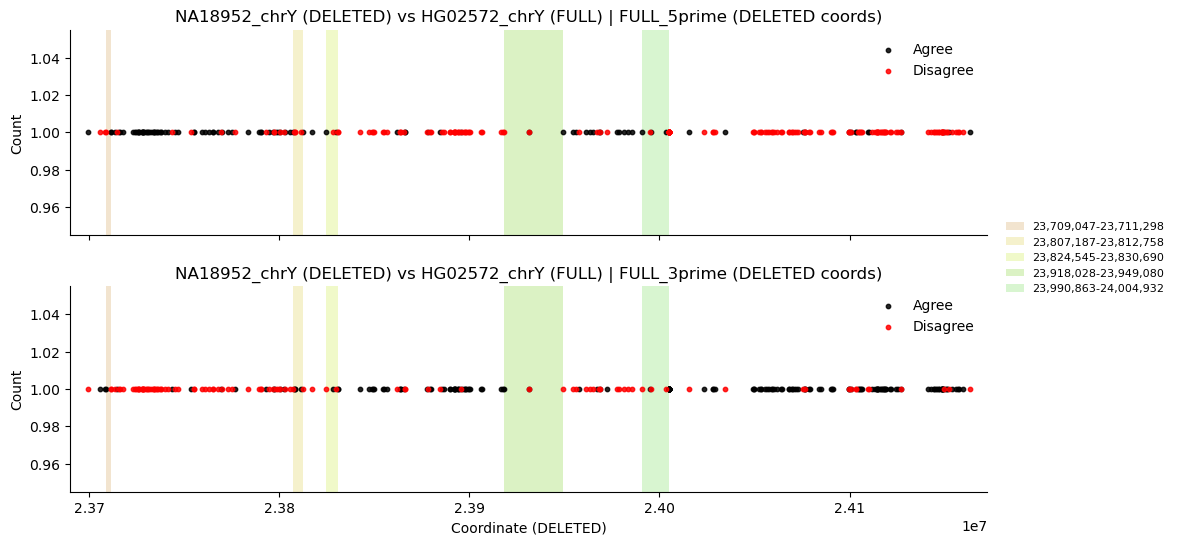


=== NA18983_HG02572_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 432445 / 478477
[DEBUG] SNP columns (no-gap; bases only): 289
[DEBUG] NA18983_chrY (DELETED) vs HG02572_chrY (FULL): skipped(full5==full3 & del!=full)=53


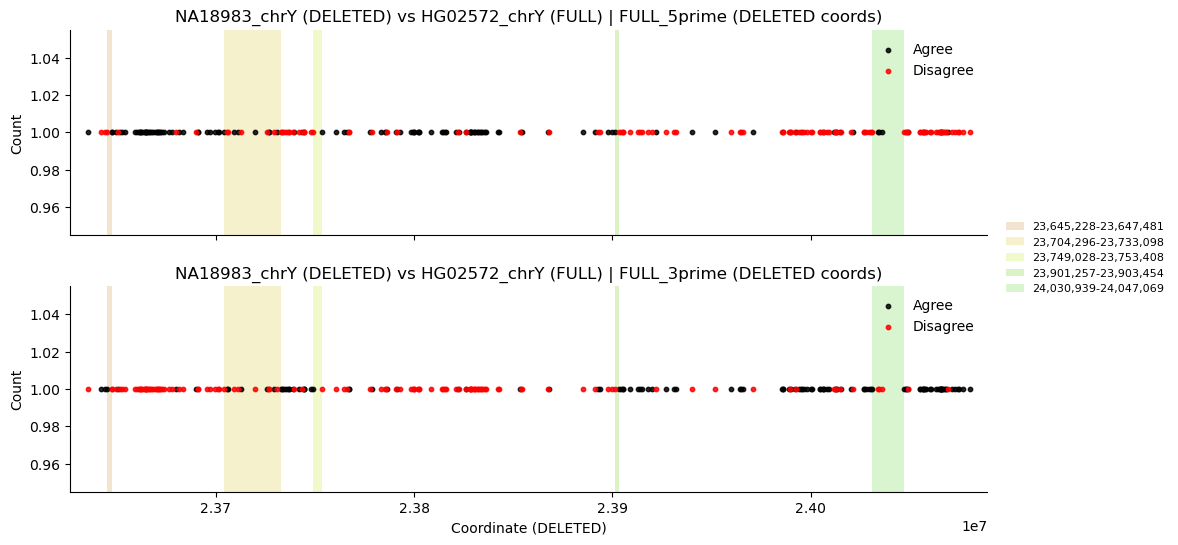


=== HG01099_HG03579_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 437226 / 476019
[DEBUG] SNP columns (no-gap; bases only): 301
[DEBUG] HG01099_chrY (DELETED) vs HG03579_chrY (FULL): skipped(full5==full3 & del!=full)=14


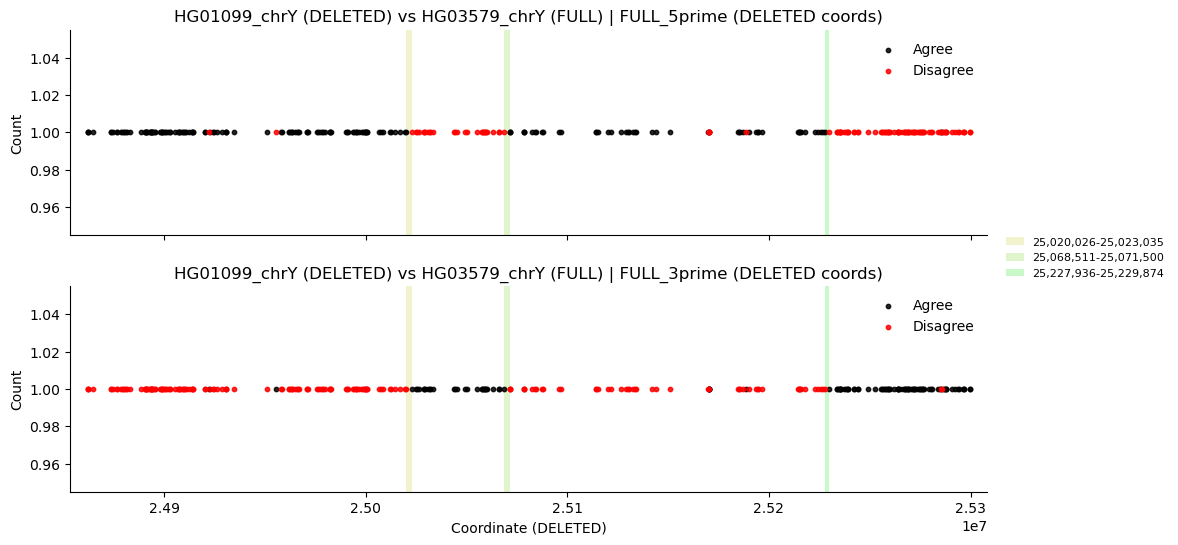


=== HG04228_HG04115_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 49959 / 50045
[DEBUG] SNP columns (no-gap; bases only): 28
[DEBUG] HG04228_chrY (DELETED) vs HG04115_chrY (FULL): skipped(full5==full3 & del!=full)=3


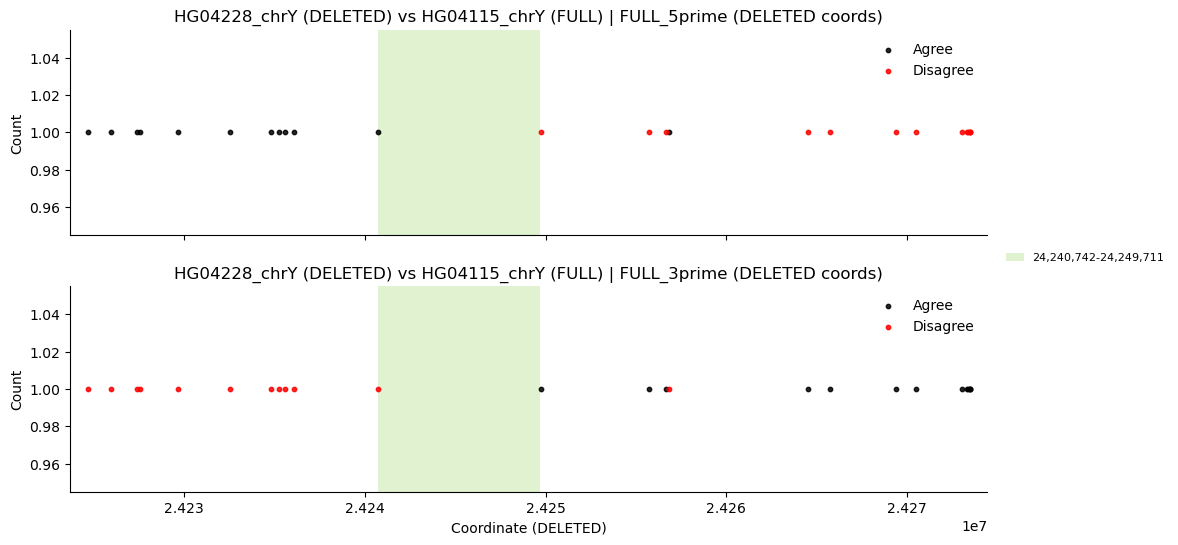


=== NA18747_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364531 / 364913
[DEBUG] SNP columns (no-gap; bases only): 236
[DEBUG] NA18747_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=34


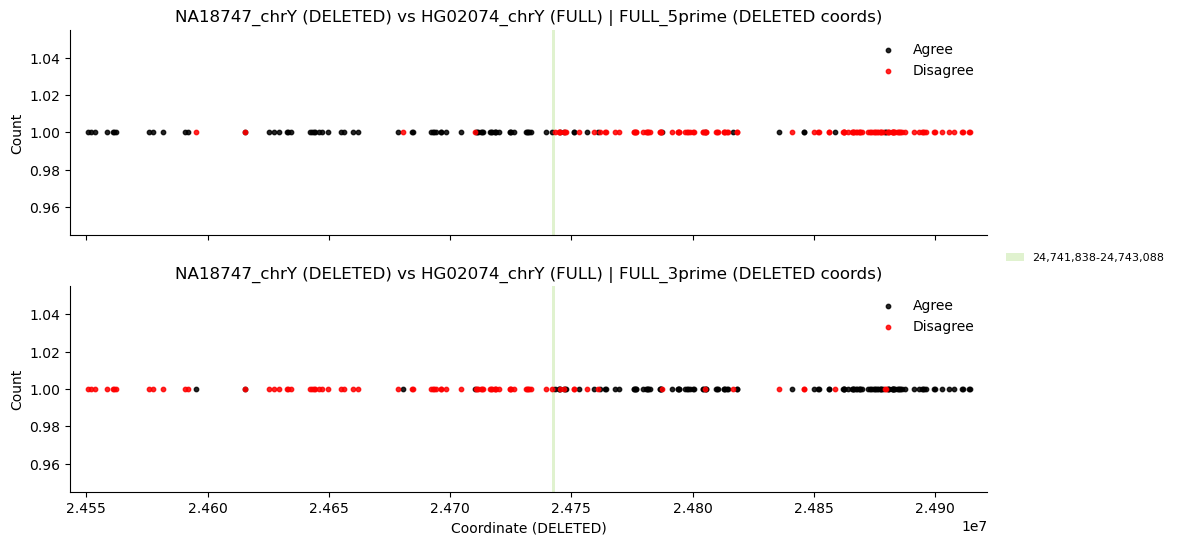


=== HG00290_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364542 / 365169
[DEBUG] SNP columns (no-gap; bases only): 242
[DEBUG] HG00290_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=31


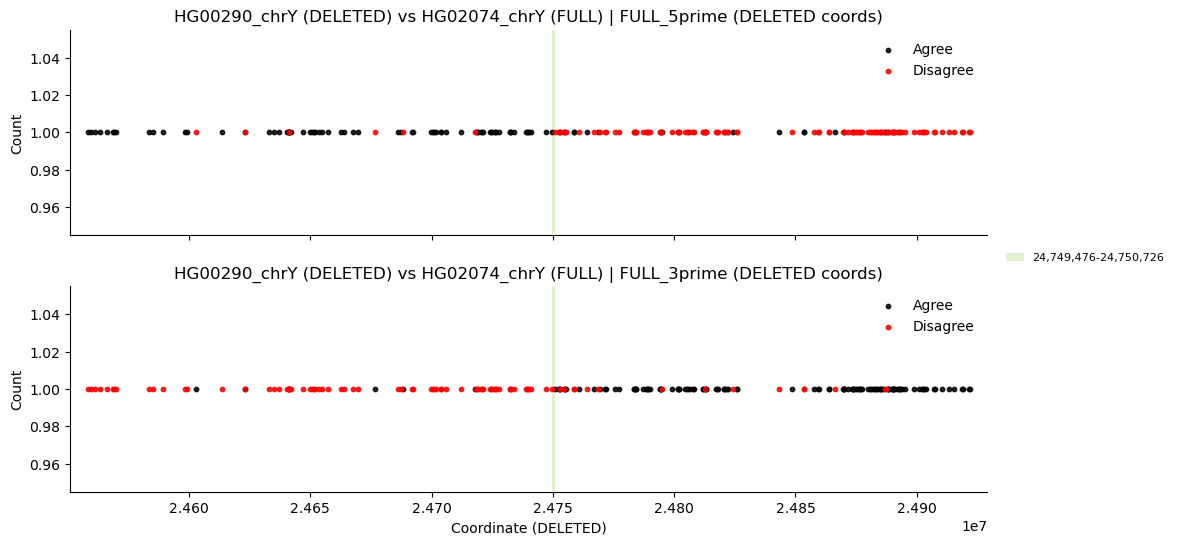


=== HG02135_HG02071_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 314626 / 314773
[DEBUG] SNP columns (no-gap; bases only): 184
[DEBUG] HG02135_chrY (DELETED) vs HG02071_chrY (FULL): skipped(full5==full3 & del!=full)=7


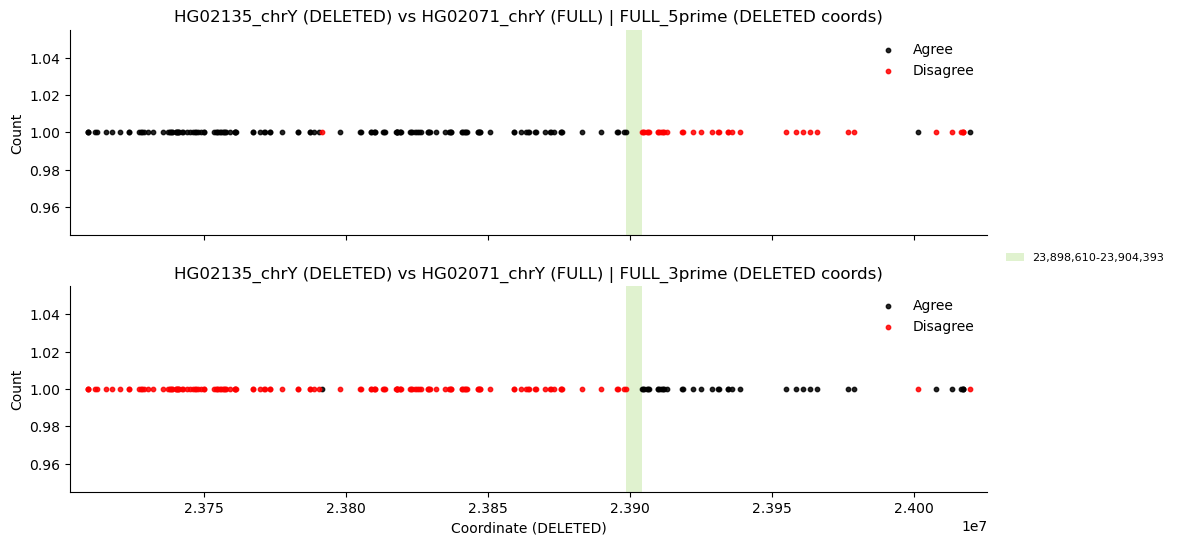


=== HG02129_HG02071_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 314630 / 314777
[DEBUG] SNP columns (no-gap; bases only): 209
[DEBUG] HG02129_chrY (DELETED) vs HG02071_chrY (FULL): skipped(full5==full3 & del!=full)=7


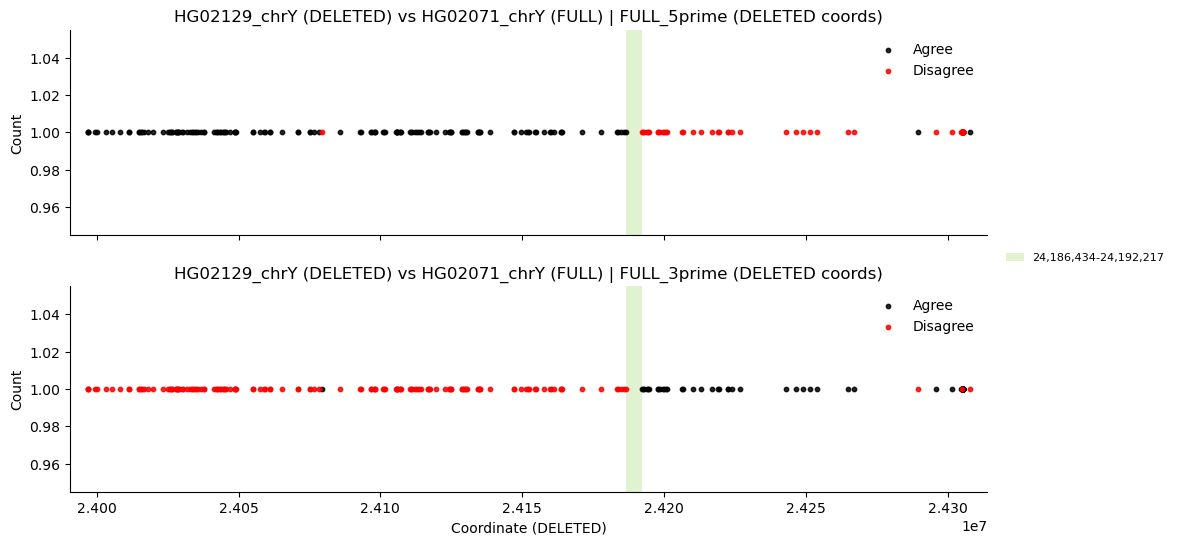


=== HG00358_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364576 / 365142
[DEBUG] SNP columns (no-gap; bases only): 238
[DEBUG] HG00358_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=31


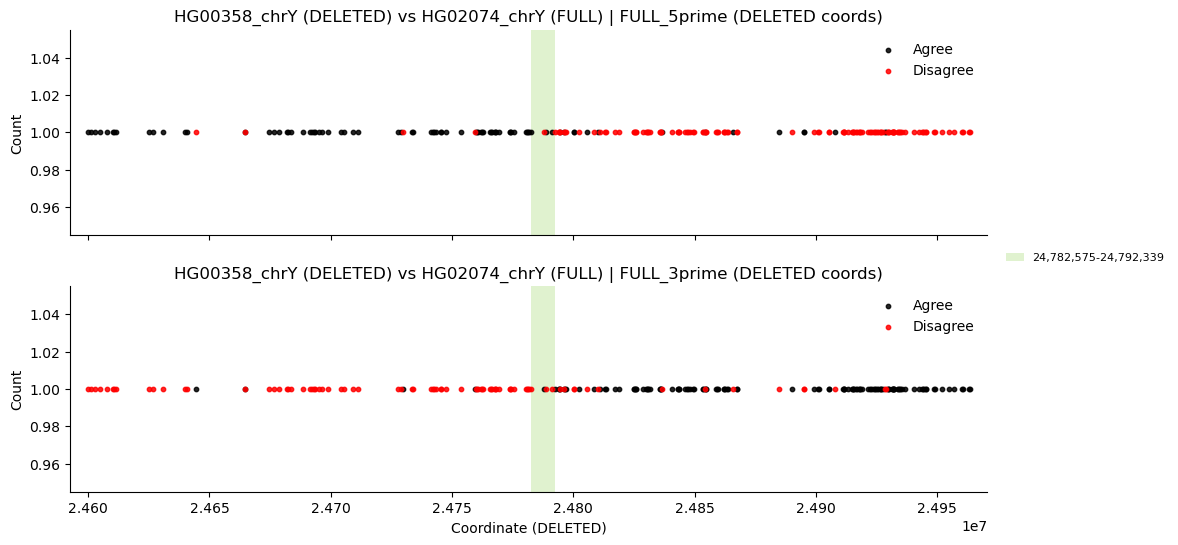


=== HG00329_HG02074_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 364590 / 365133
[DEBUG] SNP columns (no-gap; bases only): 350
[DEBUG] HG00329_chrY (DELETED) vs HG02074_chrY (FULL): skipped(full5==full3 & del!=full)=145


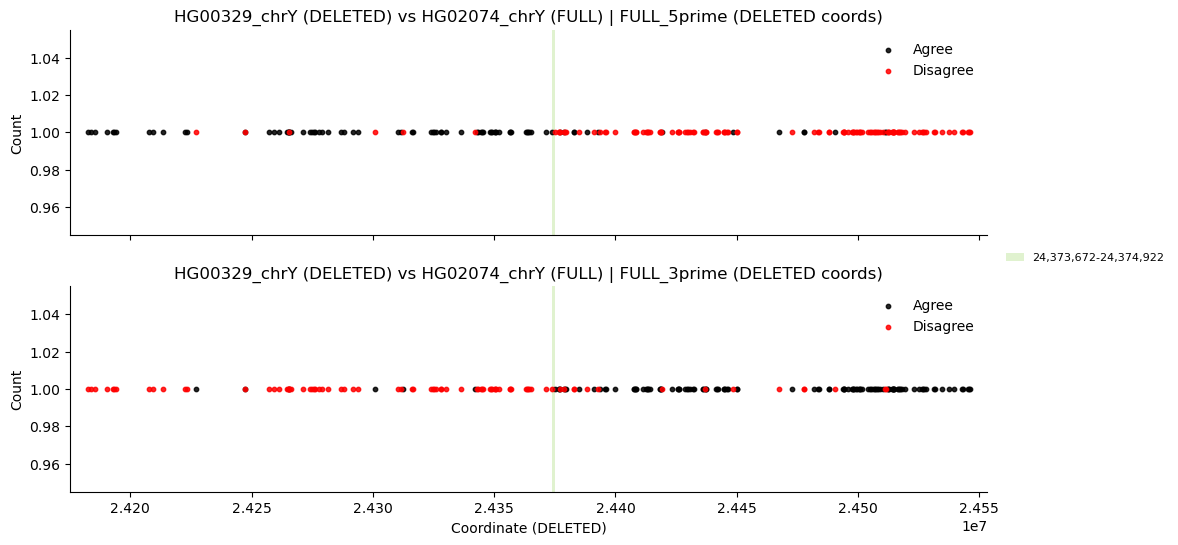


=== HG005_HG02572_deletion_breakpoint.fasta ===
[DEBUG] rows in MSA: 3
[DEBUG] triplets found: 1
[DEBUG] columns with NO gaps across all rows: 445698 / 473657
[DEBUG] SNP columns (no-gap; bases only): 300
[DEBUG] HG005_chrY (DELETED) vs HG02572_chrY (FULL): skipped(full5==full3 & del!=full)=43


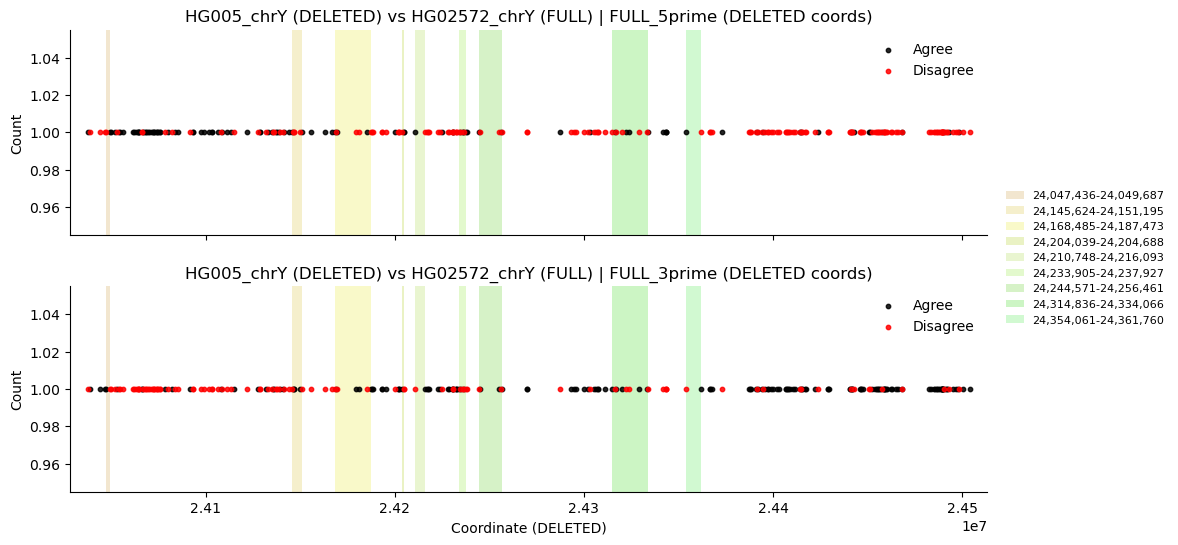

In [68]:
from __future__ import annotations

import os
import re
import json
from pathlib import Path
from typing import Union, List, Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def msa_fasta_to_df(
    fasta_path: Union[str, Path],
    *,
    long: bool = False,
    keep_gaps: bool = True,
    fill_value: str = "-",
) -> pd.DataFrame:
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {fasta_path}")

    seqs: Dict[str, str] = {}
    cur_id = None
    cur_chunks: List[str] = []

    def _commit():
        nonlocal cur_id, cur_chunks
        if cur_id is None:
            return
        seq = "".join(cur_chunks).strip()
        if not seq:
            raise ValueError(f"Empty sequence for record '{cur_id}' in {fasta_path}")
        if cur_id in seqs:
            raise ValueError(f"Duplicate FASTA header/id '{cur_id}' in {fasta_path}")
        seqs[cur_id] = seq
        cur_id, cur_chunks = None, []

    with fasta_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                _commit()
                cur_id = line[1:].split()[0]
                cur_chunks = []
            else:
                if cur_id is None:
                    raise ValueError("FASTA parse error: sequence line before any header ('>').")
                cur_chunks.append(line)
    _commit()

    if not seqs:
        raise ValueError(f"No sequences found in {fasta_path}")

    max_len = max(len(s) for s in seqs.values())
    ids = list(seqs.keys())
    mat = []
    for i in ids:
        s = seqs[i]
        if len(s) < max_len:
            s = s + (fill_value * (max_len - len(s)))
        elif len(s) > max_len:
            s = s[:max_len]
        mat.append(list(s))

    wide = pd.DataFrame(mat, index=ids, columns=pd.RangeIndex(1, max_len + 1, name="pos"))
    wide.index.name = "id"

    if not keep_gaps:
        wide = wide.replace("-", pd.NA)

    if not long:
        return wide

    long_df = (
        wide.reset_index()
            .melt(id_vars="id", var_name="pos", value_name="base")
            .sort_values(["id", "pos"], kind="stable")
            .reset_index(drop=True)
    )
    if not keep_gaps:
        long_df.loc[long_df["base"] == "-", "base"] = pd.NA
    return long_df


REGION_RE = re.compile(
    r"^(?P<contig>[^:]+):(?P<start>\d+)-(?P<end>\d+)_(?P<role>DELETED|FULL_5prime|FULL_3prime)$",
    re.IGNORECASE
)

def parse_row_id(row_id: str) -> Tuple[str, int, int, str]:
    m = REGION_RE.match(row_id)
    if not m:
        raise ValueError(f"Header does not match expected pattern contig:start-end_ROLE: {row_id}")
    contig = m.group("contig")
    start = int(m.group("start"))
    end   = int(m.group("end"))
    role  = m.group("role")
    role_u = role.upper()
    if role_u == "DELETED":
        role = "DELETED"
    elif role_u == "FULL_5PRIME":
        role = "FULL_5prime"
    elif role_u == "FULL_3PRIME":
        role = "FULL_3prime"
    return contig, start, end, role

def build_coordinate_dict(df_wide: pd.DataFrame) -> Dict[str, Dict[int, int]]:
    """
    Map alignment column -> genomic coordinate, per row.
    Skips gap characters '-' (so only real bases advance coordinate).
    """
    coordinateDict: Dict[str, Dict[int, int]] = {r: {} for r in df_wide.index}

    for r in df_wide.index:
        contig, start_bp, end_bp, role = parse_row_id(r)
        step = 1 if end_bp >= start_bp else -1
        coord = start_bp

        for c in df_wide.columns:
            base = df_wide.at[r, c]
            if base == "-":
                continue
            coordinateDict[r][int(c)] = coord
            coord += step

    return coordinateDict

def find_deletion_vs_full_triplets(row_names: List[str]) -> List[Tuple[str, str, str, str]]:
    deleted_rows: List[str] = []
    full5_by_contig: Dict[str, str] = {}
    full3_by_contig: Dict[str, str] = {}

    for r in row_names:
        contig, start, end, role = parse_row_id(r)
        if role == "DELETED":
            deleted_rows.append(r)
        elif role == "FULL_5prime":
            full5_by_contig[contig] = r
        elif role == "FULL_3prime":
            full3_by_contig[contig] = r

    full_contigs = sorted(set(full5_by_contig) & set(full3_by_contig))

    triplets: List[Tuple[str, str, str, str]] = []
    for drow in deleted_rows:
        dcontig, *_ = parse_row_id(drow)
        for fcontig in full_contigs:
            group_label = f"{dcontig} (DELETED) vs {fcontig} (FULL)"
            triplets.append((group_label, drow, full5_by_contig[fcontig], full3_by_contig[fcontig]))
    return triplets


VALID_BASES = set("ACGT")

def is_valid_base(x: str) -> bool:
    return isinstance(x, str) and (x.upper() in VALID_BASES)


def build_hits_deleted_two_panels(
    df_wide: pd.DataFrame,
    coordinateDict: Dict[str, Dict[int, int]],
    *,
    debug: bool = True,
    include_details: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    triplets = find_deletion_vs_full_triplets(list(df_wide.index))
    if debug:
        print(f"[DEBUG] rows in MSA: {df_wide.shape[0]}")
        print(f"[DEBUG] triplets found: {len(triplets)}")

    if not triplets:
        empty_df = pd.DataFrame(columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
        return empty_df, {}

    no_gap_cols = [int(col) for col in df_wide.columns if (df_wide[col] != "-").all()]
    if debug:
        print(f"[DEBUG] columns with NO gaps across all rows: {len(no_gap_cols)} / {df_wide.shape[1]}")

    snp_cols: List[int] = []
    for col in no_gap_cols:
        vals = df_wide[col].dropna().astype(str).str.upper()
        vals = vals[vals.map(lambda b: b in VALID_BASES)]
        if len(vals.unique()) >= 2:
            snp_cols.append(int(col))
    if debug:
        print(f"[DEBUG] SNP columns (no-gap; bases only): {len(snp_cols)}")

    if not snp_cols:
        empty_df = pd.DataFrame(columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
        return empty_df, {}

    out_rows: List[List[Any]] = []
    snp_dict: Dict[str, Any] = {}

    for group_label, drow, f5row, f3row in triplets:
        snp_dict.setdefault(group_label, {})
        for side in ["FULL_5prime", "FULL_3prime"]:
            snp_dict[group_label].setdefault(side, {
                "agree_coords": [],
                "disagree_coords": [],
                "agree_details": [] if include_details else None,
                "disagree_details": [] if include_details else None,
            })

        skipped_full_agree_deleted_diff = 0

        for col in snp_cols:
            b_del = str(df_wide.at[drow, col]).upper()
            b5    = str(df_wide.at[f5row, col]).upper()
            b3    = str(df_wide.at[f3row, col]).upper()

            del_ok = is_valid_base(b_del)
            b5_ok  = is_valid_base(b5)
            b3_ok  = is_valid_base(b3)

            if del_ok and b5_ok and b3_ok and (b5 == b3) and (b_del != b5):
                skipped_full_agree_deleted_diff += 1
                continue

            coord = coordinateDict.get(drow, {}).get(int(col))
            if coord is None:
                continue

            if del_ok and b5_ok:
                mt = "Agree" if (b_del == b5) else "Disagree"
                out_rows.append([group_label, "FULL_5prime", int(coord), 1, mt])
                if mt == "Agree":
                    snp_dict[group_label]["FULL_5prime"]["agree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_5prime"]["agree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b5}
                        )
                else:
                    snp_dict[group_label]["FULL_5prime"]["disagree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_5prime"]["disagree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b5}
                        )

            if del_ok and b3_ok:
                mt = "Agree" if (b_del == b3) else "Disagree"
                out_rows.append([group_label, "FULL_3prime", int(coord), 1, mt])
                if mt == "Agree":
                    snp_dict[group_label]["FULL_3prime"]["agree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_3prime"]["agree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b3}
                        )
                else:
                    snp_dict[group_label]["FULL_3prime"]["disagree_coords"].append(int(coord))
                    if include_details:
                        snp_dict[group_label]["FULL_3prime"]["disagree_details"].append(
                            {"coord": int(coord), "col": int(col), "deleted_base": b_del, "full_base": b3}
                        )

        for side in ["FULL_5prime", "FULL_3prime"]:
            snp_dict[group_label][side]["agree_coords"] = sorted(set(snp_dict[group_label][side]["agree_coords"]))
            snp_dict[group_label][side]["disagree_coords"] = sorted(set(snp_dict[group_label][side]["disagree_coords"]))
            if include_details:
                snp_dict[group_label][side]["agree_details"].sort(key=lambda x: (x["coord"], x["col"]))
                snp_dict[group_label][side]["disagree_details"].sort(key=lambda x: (x["coord"], x["col"]))

        if debug:
            print(f"[DEBUG] {group_label}: skipped(full5==full3 & del!=full)={skipped_full_agree_deleted_diff}")

    hits_df = pd.DataFrame(out_rows, columns=["Group", "Side", "Coordinate", "Hit", "MatchType"])
    return hits_df, snp_dict

def get_run_blocks_from_details(side_block: dict, *, use_details: bool = True):
    """
    Build consecutive run blocks (Agree/Disagree) along DELETED coordinates,
    while carrying alignment columns per site so gaps can be mapped back to FULL coords.
    """
    agree_details = side_block.get("agree_details")
    disagree_details = side_block.get("disagree_details")

    sites = [] 

    if use_details and isinstance(agree_details, list) and isinstance(disagree_details, list):
        for d in agree_details:
            if "coord" in d and "col" in d:
                sites.append((int(d["coord"]), int(d["col"]), "Agree"))
        for d in disagree_details:
            if "coord" in d and "col" in d:
                sites.append((int(d["coord"]), int(d["col"]), "Disagree"))
    else:
        for c in side_block.get("agree_coords", []):
            sites.append((int(c), None, "Agree"))
        for c in side_block.get("disagree_coords", []):
            sites.append((int(c), None, "Disagree"))

    if not sites:
        return []

    sites.sort(key=lambda x: (x[0], 0 if x[2] == "Agree" else 1))

    collapsed = []
    i = 0
    while i < len(sites):
        coord = sites[i][0]
        chunk = []
        j = i
        while j < len(sites) and sites[j][0] == coord:
            chunk.append(sites[j])
            j += 1

        if len(chunk) == 1:
            collapsed.append(chunk[0])
        else:
            a = sum(1 for _, _, s in chunk if s == "Agree")
            d = sum(1 for _, _, s in chunk if s == "Disagree")
            state = "Agree" if a > d else ("Disagree" if d > a else "Mixed")
            cols = sorted([c for _, c, _ in chunk if c is not None])
            rep_col = cols[len(cols) // 2] if cols else None
            collapsed.append((coord, rep_col, state))

        i = j

    blocks = []
    cur_state = collapsed[0][2]
    cur_coords = [collapsed[0][0]]
    cur_cols = [collapsed[0][1]]

    for coord, col, state in collapsed[1:]:
        if state == cur_state:
            cur_coords.append(coord)
            cur_cols.append(col)
        else:
            blocks.append({
                "state": cur_state,
                "start": cur_coords[0],
                "end": cur_coords[-1],
                "n_sites": len(cur_coords),
                "coords": cur_coords,
                "cols": cur_cols,
                "start_col": next((x for x in cur_cols if x is not None), None),
                "end_col": next((x for x in reversed(cur_cols) if x is not None), None),
            })
            cur_state = state
            cur_coords = [coord]
            cur_cols = [col]

    blocks.append({
        "state": cur_state,
        "start": cur_coords[0],
        "end": cur_coords[-1],
        "n_sites": len(cur_coords),
        "coords": cur_coords,
        "cols": cur_cols,
        "start_col": next((x for x in cur_cols if x is not None), None),
        "end_col": next((x for x in reversed(cur_cols) if x is not None), None),
    })

    return blocks


def merge_adjacent_same_state(blocks):
    if not blocks:
        return []
    merged = [blocks[0].copy()]
    for b in blocks[1:]:
        last = merged[-1]
        if b["state"] == last["state"]:
            last["end"] = b["end"]
            last["n_sites"] += b["n_sites"]
            last["coords"] = last["coords"] + b["coords"]
            last["cols"] = last.get("cols", []) + b.get("cols", [])
            cols = [c for c in last["cols"] if c is not None]
            last["start_col"] = cols[0] if cols else last.get("start_col")
            last["end_col"]   = cols[-1] if cols else last.get("end_col")
        else:
            merged.append(b.copy())
    return merged


def compute_gap_windows_between_blocks(blocks):
    """
    Gap windows in DELETED coordinates, PLUS alignment-column anchors bracketing the gap.
      left_col  = alignment column at end of left block
      right_col = alignment column at start of right block
    """
    if not blocks:
        return []
    blocks = sorted(blocks, key=lambda b: (b["start"], b["end"]))
    gaps = []
    for left, right in zip(blocks, blocks[1:]):
        gap_start = int(left["end"]) + 1
        gap_end   = int(right["start"]) - 1
        if gap_end < gap_start:
            continue
        gaps.append({
            "gap_start": gap_start,
            "gap_end": gap_end,
            "gap_len": int(gap_end - gap_start + 1),
            "left_state": left["state"],
            "right_state": right["state"],
            "left_end": int(left["end"]),
            "right_start": int(right["start"]),
            "left_col": left.get("end_col"),
            "right_col": right.get("start_col"),
        })
    return gaps


def merge_gap_windows(gaps, *, max_merge_bp: int = 5000):
    """
    Merge gap windows if they are within max_merge_bp of each other (DELETED coords).
    Keeps anchors so we can map to FULL coords later:
      - left_col: earliest left anchor in the merged run
      - right_col: latest right anchor in the merged run
    """
    if not gaps:
        return []

    gaps = sorted(gaps, key=lambda g: (int(g["gap_start"]), int(g["gap_end"])))

    merged = []
    cur = {
        "gap_start": int(gaps[0]["gap_start"]),
        "gap_end": int(gaps[0]["gap_end"]),
        "source_gaps": [gaps[0]],
        "left_state": gaps[0].get("left_state"),
        "right_state": gaps[0].get("right_state"),
        "left_col": gaps[0].get("left_col"),
        "right_col": gaps[0].get("right_col"),
    }

    for g in gaps[1:]:
        gs = int(g["gap_start"])
        ge = int(g["gap_end"])

        if gs <= (cur["gap_end"] + 1 + max_merge_bp):
            cur["gap_end"] = max(cur["gap_end"], ge)
            cur["source_gaps"].append(g)
            cur["right_state"] = g.get("right_state", cur["right_state"])
            if cur["left_col"] is None:
                cur["left_col"] = g.get("left_col")
            if g.get("right_col") is not None:
                cur["right_col"] = g.get("right_col")
        else:
            cur["gap_len"] = int(cur["gap_end"] - cur["gap_start"] + 1)
            cur["n_gaps_merged"] = len(cur["source_gaps"])
            merged.append(cur)

            cur = {
                "gap_start": gs,
                "gap_end": ge,
                "source_gaps": [g],
                "left_state": g.get("left_state"),
                "right_state": g.get("right_state"),
                "left_col": g.get("left_col"),
                "right_col": g.get("right_col"),
            }

    cur["gap_len"] = int(cur["gap_end"] - cur["gap_start"] + 1)
    cur["n_gaps_merged"] = len(cur["source_gaps"])
    merged.append(cur)

    return merged


def call_blocks_and_gaps_for_group_full5(
    snp_dict_group: dict,
    *,
    merge_gaps_within_bp: int = 5000,
    min_block_sites: int = 3,
):
    """
    Call FULL_5prime blocks (Agree/Disagree runs) in DELETED coordinates,
    then derive gap windows between those blocks, then merge nearby gaps.
    """
    block_5prime = snp_dict_group.get("FULL_5prime", {})
    blocks = get_run_blocks_from_details(block_5prime, use_details=True)

    blocks = [b for b in blocks if b["n_sites"] >= min_block_sites]

    blocks = merge_adjacent_same_state(blocks)

    gaps = compute_gap_windows_between_blocks(blocks)

    gaps = merge_gap_windows(gaps, max_merge_bp=merge_gaps_within_bp)

    return blocks, gaps


def gaps_to_full_coords_and_sizes(
    gaps: List[dict],
    *,
    full5_row: str,
    full3_row: str,
    coordinateDict: Dict[str, Dict[int, int]],
) -> List[dict]:
    """
    For each gap (defined in DELETED coords), use its alignment anchors to get:
      - full5_bp_at_left:  FULL_5prime coord at left_col
      - full3_bp_at_right: FULL_3prime coord at right_col
      - max_del_size_full_bp: abs(full3 - full5) - 1

    Returns list of dicts (same gap dict plus added keys).
    """
    out = []
    for g in gaps:
        left_col = g.get("left_col")
        right_col = g.get("right_col")

        full5_bp = None
        full3_bp = None

        if left_col is not None:
            full5_bp = coordinateDict.get(full5_row, {}).get(int(left_col))
        if right_col is not None:
            full3_bp = coordinateDict.get(full3_row, {}).get(int(right_col))

        if full5_bp is not None and full3_bp is not None:
            max_del = abs(int(full3_bp) - int(full5_bp)) - 1
        else:
            max_del = None

        gg = dict(g)
        gg["full5_bp_at_left"] = full5_bp
        gg["full3_bp_at_right"] = full3_bp
        gg["max_del_size_full_bp"] = max_del
        out.append(gg)

    return out


def plot_deleted_two_panels_with_gaps(
    hits_df: pd.DataFrame,
    *,
    gap_windows_by_group: Optional[Dict[str, List[dict]]] = None,  
    outFile: Optional[str] = None,
    save_jpeg: bool = True,
    jpeg_dpi: int = 300,
    jpeg_quality: int = 95,
    point_size: float = 10,
    alpha: float = 0.85,
    gap_alpha: float = 0.25,
    seed: int = 123,
    legend_max_gaps: int = 20,
    legend_fontsize: int = 8,
    legend_ncol: int = 1,
    legend_right_pad: float = 0.78,
):
    if hits_df.empty:
        print("No SNP hits to plot.")
        return

    import colorsys
    from matplotlib.patches import Patch

    agg = (
        hits_df.groupby(["Group", "Side", "Coordinate", "MatchType"], as_index=False)["Hit"]
        .sum()
    )

    side_order = ["FULL_5prime", "FULL_3prime"]
    rng = np.random.default_rng(seed)

    def _distinct_gap_colors(n: int):
        if n <= 0:
            return []
        hues = np.linspace(0, 1, n * 4, endpoint=False)
        good = []
        for h in hues:
            if (h < 0.06) or (h > 0.94) or (0.06 <= h < 0.10):
                continue
            good.append(float(h))
            if len(good) >= n:
                break
        if len(good) < n:
            good = [float((0.12 + i / max(1, n) * 0.76) % 1.0) for i in range(n)]

        cols = []
        for i, h in enumerate(good[:n]):
            s = 0.68 + 0.22 * ((i % 4) / 3.0)
            v = 0.80 + 0.12 * ((i % 3) / 2.0)
            r, g, b = colorsys.hsv_to_rgb(h, s, v)
            cols.append((r, g, b))
        return cols

    for group in sorted(agg["Group"].unique()):
        subg = agg[agg["Group"] == group].copy()

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        fig.subplots_adjust(right=legend_right_pad, hspace=0.25)

        xmin = int(subg["Coordinate"].min())
        xmax = int(subg["Coordinate"].max())
        pad = max(50, int((xmax - xmin) * 0.02))
        xlim = (xmin - pad, xmax + pad)

        gaps = (gap_windows_by_group or {}).get(group, [])
        gaps = sorted(gaps, key=lambda g: (int(g["gap_start"]), int(g["gap_end"])))

        gap_colors = _distinct_gap_colors(len(gaps))

        gap_handles = []
        if gaps:
            lens = [int(g.get("gap_len", int(g["gap_end"]) - int(g["gap_start"]) + 1)) for g in gaps]
            if len(gaps) > legend_max_gaps:
                keep_idx = np.argsort([-L for L in lens])[:legend_max_gaps]
                keep = set(keep_idx.tolist())
                legend_items = [(i, gaps[i], gap_colors[i], lens[i]) for i in range(len(gaps)) if i in keep]
                legend_items.sort(key=lambda x: (int(x[1]["gap_start"]), int(x[1]["gap_end"])))
                trimmed = True
            else:
                legend_items = [(i, g, c, L) for i, (g, c, L) in enumerate(zip(gaps, gap_colors, lens))]
                trimmed = False

            for i, g, col, L in legend_items:
                label = f"{int(g['gap_start']):,}-{int(g['gap_end']):,}"
                gap_handles.append(Patch(facecolor=col, edgecolor="none", alpha=gap_alpha, label=label))

            if trimmed:
                gap_handles.append(
                    Patch(facecolor="white", edgecolor="none",
                          label=f"... ({len(gaps)-legend_max_gaps} more gaps not shown)")
                )

        for ax, side in zip(axes, side_order):
            sub = subg[subg["Side"] == side]
            if sub.empty:
                ax.set_title(f"{group} | {side} (no data)")
                ax.set_axis_off()
                continue

            for g, col in zip(gaps, gap_colors):
                ax.axvspan(int(g["gap_start"]), int(g["gap_end"]), alpha=gap_alpha, color=col, linewidth=0)

            for mt, color in [("Agree", "black"), ("Disagree", "red")]:
                ssub = sub[sub["MatchType"] == mt]
                if ssub.empty:
                    continue
                ax.scatter(
                    ssub["Coordinate"].astype(int).values,
                    ssub["Hit"].values,
                    s=point_size,
                    alpha=alpha,
                    c=color,
                    label=mt
                )

            ax.set_xlim(*xlim)
            ax.set_ylabel("Count")
            ax.set_title(f"{group} | {side} (DELETED coords)")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            snp_handles, snp_labels = ax.get_legend_handles_labels()
            if snp_handles:
                ax.legend(snp_handles, snp_labels, frameon=False, loc="upper right")

        axes[-1].set_xlabel("Coordinate (DELETED)")

        if gap_handles:
            fig.legend(
                handles=gap_handles,
                loc="center left",
                bbox_to_anchor=(legend_right_pad + 0.01, 0.5),
                frameon=False,
                fontsize=legend_fontsize,
                ncol=legend_ncol,
                borderaxespad=0.0,
                handlelength=1.6,
                columnspacing=1.0,
                labelspacing=0.5,
            )

        if outFile:
            safe = re.sub(r"[^A-Za-z0-9]+", "_", group)
            if outFile.lower().endswith(".pdf"):
                pdf_path = outFile.replace(".pdf", f"__{safe}.pdf")
            else:
                pdf_path = outFile + f"__{safe}.pdf"

            plt.savefig(pdf_path, dpi=300, bbox_inches="tight")

            if save_jpeg:
                jpg_path = re.sub(r"\.pdf$", ".jpg", pdf_path, flags=re.IGNORECASE)
                try:
                    plt.savefig(
                        jpg_path,
                        dpi=jpeg_dpi,
                        bbox_inches="tight",
                        pil_kwargs={"quality": int(jpeg_quality), "subsampling": 0}
                    )
                except TypeError:
                    plt.savefig(jpg_path, dpi=jpeg_dpi, bbox_inches="tight")

        plt.show()


directory = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Good_Alignments/"
out_dir   = "/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Breakpoints/"
os.makedirs(out_dir, exist_ok=True)

all_breakpoint_rows: List[Dict[str, Any]] = []

for fastaFile in os.listdir(directory):
    if not fastaFile.endswith(".fasta"):
        continue

    print(f"\n=== {fastaFile} ===")
    outFilePath = os.path.join(out_dir, f"DELETION_{fastaFile.split('.fasta')[0]}.pdf")

    df_wide = msa_fasta_to_df(os.path.join(directory, fastaFile))
    coordinateDict = build_coordinate_dict(df_wide)

    hits_df, snp_dict = build_hits_deleted_two_panels(
        df_wide,
        coordinateDict,
        debug=True,
        include_details=True
    )

    json_out = outFilePath.replace(".pdf", ".no_gap_cols.deleted_two_panels.snp_dict.json")
    with open(json_out, "w") as f:
        json.dump(snp_dict, f, indent=2)

    triplets = find_deletion_vs_full_triplets(list(df_wide.index))
    group2rows = {g: (drow, f5row, f3row) for g, drow, f5row, f3row in triplets}

    gap_windows_by_group: Dict[str, List[dict]] = {}
    blocks_by_group: Dict[str, List[dict]] = {}

    for group_label, group_block in snp_dict.items():
        blocks, gaps = call_blocks_and_gaps_for_group_full5(
            group_block,
            merge_gaps_within_bp=5000,
            min_block_sites=3,
        )
        blocks_by_group[group_label] = blocks

        if group_label in group2rows:
            drow, f5row, f3row = group2rows[group_label]
            gaps_annot = gaps_to_full_coords_and_sizes(
                gaps,
                full5_row=f5row,
                full3_row=f3row,
                coordinateDict=coordinateDict
            )
        else:
            drow, f5row, f3row = (None, None, None)
            gaps_annot = [dict(g, full5_bp_at_left=None, full3_bp_at_right=None, max_del_size_full_bp=None) for g in gaps]

        gap_windows_by_group[group_label] = gaps_annot

        deleted_contig = group_label.split(" (DELETED)")[0].strip()
        full_contig = group_label.split(" vs ")[-1].split(" (FULL)")[0].strip() if " vs " in group_label else None

        for g in gaps_annot:
            all_breakpoint_rows.append({
                "fasta": fastaFile,
                "group": group_label,
                "deleted_contig": deleted_contig,
                "full_contig": full_contig,
                "deleted_row": drow,
                "full5_row": f5row,
                "full3_row": f3row,
                # DELETED-coordinate window 
                "gap_start_deleted": int(g["gap_start"]),
                "gap_end_deleted": int(g["gap_end"]),
                "gap_len_deleted_bp": int(g.get("gap_len", int(g["gap_end"]) - int(g["gap_start"]) + 1)),
                "n_gaps_merged": int(g.get("n_gaps_merged", 1)),
                # FULL-coordinate anchors + max deletion size in FULL coords 
                "full5_bp_at_left": g.get("full5_bp_at_left"),
                "full3_bp_at_right": g.get("full3_bp_at_right"),
                "max_del_size_full_bp": g.get("max_del_size_full_bp"),
                "left_state": g.get("left_state"),
                "right_state": g.get("right_state"),
                "left_col_anchor": g.get("left_col"),
                "right_col_anchor": g.get("right_col"),
            })

    blocks_out = outFilePath.replace(".pdf", ".FULL_5prime.blocks.json")
    gaps_out   = outFilePath.replace(".pdf", ".FULL_5prime.gaps.merged_5kb.json")
    with open(blocks_out, "w") as f:
        json.dump(blocks_by_group, f, indent=2)
    with open(gaps_out, "w") as f:
        json.dump(gap_windows_by_group, f, indent=2)

    plot_deleted_two_panels_with_gaps(
        hits_df,
        gap_windows_by_group=gap_windows_by_group,
        outFile=outFilePath,
        legend_ncol=1,
        save_jpeg=True,
        jpeg_dpi=300,
    )

if all_breakpoint_rows:
    bp_df = pd.DataFrame(all_breakpoint_rows)
    bp_df = bp_df.sort_values(
        by=["deleted_contig", "full_contig", "gap_start_deleted", "gap_end_deleted"],
        kind="stable"
    ).reset_index(drop=True)

else:
    print("\nNo breakpoint windows were found across the processed FASTA files.")


In [93]:
#bp_df[['deleted_contig','gap_start_deleted','gap_end_deleted','gap_len_deleted_bp','full_contig','full5_bp_at_left','full3_bp_at_right','max_del_size_full_bp']].set_index('deleted_contig').sort_values(by=['full_contig']).to_csv('/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Deletion_Samples_BreakpointWindows.csv')